🚀 BẮT ĐẦU QUY TRÌNH KIỂM TRA ĐỘC LẬP...
✅ Scale Factor: 34.5496
✅ Đã load Models thành công.

📸 Đang tạo chuỗi biến hình...
⏳ Đang quét và lọc landmark cho 10 ảnh...


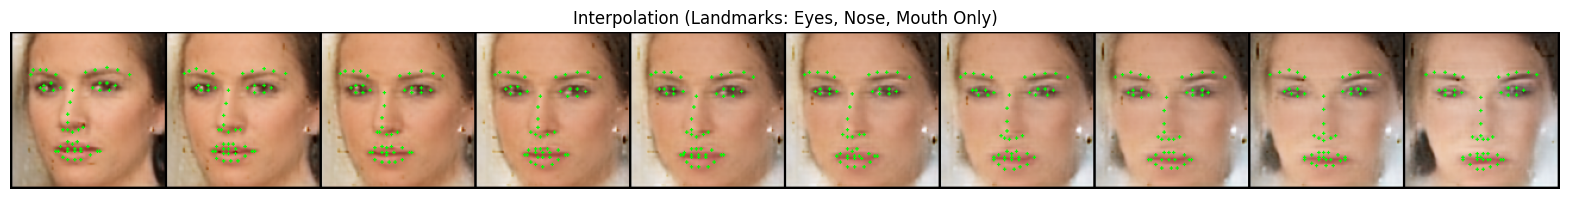


✅ Hoàn tất! Bạn sẽ thấy các chấm xanh chỉ tập trung ở vùng giữa mặt.


In [ ]:
# ==========================================
# 1. CÀI ĐẶT & IMPORT (CHẠY ĐẦU TIÊN)
# ==========================================
# Cài đặt thư viện nếu chưa có
try:
    import face_alignment
except ImportError:
    print("⏳ Đang cài đặt thư viện face-alignment...")
    !pip install face-alignment -q
    import face_alignment

import cv2
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import torchvision.utils as vutils
import os
from google.colab import drive

# ==========================================
# 2. CẤU HÌNH HỆ THỐNG
# ==========================================
# Mount Google Drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# --- ĐƯỜNG DẪN (HÃY KIỂM TRA LẠI) ---
PROJECT_DIR = "/content/drive/MyDrive/BEGAN_PROJECT"
LGEN_PATH = os.path.join(PROJECT_DIR, "l_generator_final.pth")
DECODER_PATH = os.path.join(PROJECT_DIR, "began_checkpoints/latest_checkpoint.pth")
SCALE_FILE = os.path.join(PROJECT_DIR, "z_scale_factor.npy")

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
Z_DIM = 64
NOISE_DIM = 64

# ==========================================
# 3. ĐỊNH NGHĨA MODEL (CẦN THIẾT ĐỂ LOAD WEIGHT)
# ==========================================
class L_Generator(nn.Module):
    def __init__(self):
        super(L_Generator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(NOISE_DIM, 1024), nn.LeakyReLU(0.2),
            nn.Linear(1024, 1024), nn.LeakyReLU(0.2),
            nn.Linear(1024, Z_DIM), nn.Tanh()
        )
    def forward(self, x): return self.net(x)

class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()
        self.fc = nn.Linear(Z_DIM, 8 * 8 * 64)
        self.layers = nn.Sequential(
            nn.Conv2d(64, 64, 3, 1, 1), nn.ELU(), nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 64, 3, 1, 1), nn.ELU(), nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 64, 3, 1, 1), nn.ELU(), nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 64, 3, 1, 1), nn.ELU(), nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 64, 3, 1, 1), nn.ELU(),
            nn.Conv2d(64, 3, 3, 1, 1), nn.Tanh()
        )
    def forward(self, x):
        x = self.fc(x)
        x = x.view(-1, 64, 8, 8)
        return self.layers(x)

# ==========================================
# 4. HÀM XỬ LÝ LANDMARK (ĐÃ ĐIỀU CHỈNH)
# ==========================================
def apply_internal_landmarks(images_tensor):
    """
    Sử dụng Face Alignment nhưng CHỈ VẼ các điểm nội bộ (Mắt, Mũi, Miệng).
    Loại bỏ điểm 0-16 (Hàm).
    """
    # Xử lý phiên bản LandmarksType
    try:
        landmark_type = face_alignment.LandmarksType.TWO_D
    except AttributeError:
        landmark_type = face_alignment.LandmarksType._2D

    # Khởi tạo Face Alignment
    # face_alignment đôi khi in ra warning, ta có thể bỏ qua
    fa = face_alignment.FaceAlignment(landmark_type, device=DEVICE, flip_input=False)

    output_list = []

    # Chuyển tensor sang numpy ảnh (H, W, 3) chuẩn RGB
    # Input tensor: (Batch, 3, 128, 128) -> Output numpy: (Batch, 128, 128, 3)
    images_np = images_tensor.cpu().permute(0, 2, 3, 1).detach().numpy()

    # Denormalize: [-1, 1] -> [0, 255]
    images_np = ((images_np + 1) / 2.0 * 255).astype(np.uint8)

    print(f"⏳ Đang quét và lọc landmark cho {len(images_np)} ảnh...")

    for i in range(len(images_np)):
        img = images_np[i].copy()

        try:
            preds = fa.get_landmarks(img)

            if preds:
                points = preds[0] # Lấy khuôn mặt đầu tiên

                # --- [QUAN TRỌNG] LỌC ĐIỂM ---
                # Điểm 0-16 là hàm. Ta chỉ lấy từ index 17 trở đi.
                internal_points = points[17:]

                # Vẽ điểm
                for p in internal_points:
                    x, y = int(p[0]), int(p[1])
                    # Vẽ chấm xanh lá cây (Green), nhỏ gọn
                    cv2.circle(img, (x, y), 1, (0, 255, 0), -1)
            else:
                # Không tìm thấy mặt -> Viền đỏ
                cv2.rectangle(img, (0,0), (127,127), (255,0,0), 1)

        except Exception as e:
            print(f"⚠️ Lỗi xử lý ảnh {i}: {e}")

        # Chuyển lại về Tensor (3, H, W) và Normalize về 0-1
        output_list.append(torch.from_numpy(img).permute(2, 0, 1))

    return torch.stack(output_list).float() / 255.0

# ==========================================
# 5. HÀM CHẠY CHÍNH (MAIN EXECUTION)
# ==========================================
def main_check():
    print("🚀 BẮT ĐẦU QUY TRÌNH KIỂM TRA ĐỘC LẬP...")

    # 1. Load các file cấu hình
    if not os.path.exists(SCALE_FILE):
        print(f"❌ LỖI: Không tìm thấy file {SCALE_FILE}")
        return
    scale_factor = float(np.load(SCALE_FILE)[0])
    print(f"✅ Scale Factor: {scale_factor:.4f}")

    # 2. Load Model
    l_gen = L_Generator().to(DEVICE)
    decoder = Decoder().to(DEVICE)

    try:
        l_gen.load_state_dict(torch.load(LGEN_PATH, map_location=DEVICE))

        checkpoint = torch.load(DECODER_PATH, map_location=DEVICE)
        if isinstance(checkpoint, dict) and 'generator_state_dict' in checkpoint:
            decoder.load_state_dict(checkpoint['generator_state_dict'])
        else:
            decoder.load_state_dict(checkpoint)

        l_gen.eval()
        decoder.eval()
        print("✅ Đã load Models thành công.")
    except Exception as e:
        print(f"❌ Lỗi load model: {e}")
        return

    # 3. Tạo ảnh biến hình (Interpolation)
    print("\n📸 Đang tạo chuỗi biến hình...")
    with torch.no_grad():
        noise_A = torch.randn(1, NOISE_DIM).to(DEVICE)
        noise_B = torch.randn(1, NOISE_DIM).to(DEVICE)
        steps = 10
        alphas = np.linspace(0, 1, steps)

        img_list = []
        for alpha in alphas:
            z = l_gen(noise_A * (1 - alpha) + noise_B * alpha) * scale_factor
            img_list.append(decoder(z))

        batch_imgs = torch.cat(img_list, dim=0)

    # 4. Áp dụng Landmark đã lọc
    final_imgs = apply_internal_landmarks(batch_imgs)

    # 5. Hiển thị
    plt.figure(figsize=(20, 6))
    plt.axis("off")
    plt.title("Interpolation (Landmarks: Eyes, Nose, Mouth Only)")
    plt.imshow(vutils.make_grid(final_imgs, nrow=steps, padding=2).permute(1, 2, 0))
    plt.show()

    print("\n✅ Hoàn tất! Bạn sẽ thấy các chấm xanh chỉ tập trung ở vùng giữa mặt.")

if __name__ == "__main__":
    main_check()

Để làm được điều này mà không cần dùng đến các bộ detect landmark (như Dlib hay Face-Alignment) trong quá trình sinh ảnh, chúng ta sẽ sử dụng một kỹ thuật nâng cao gọi là "Landmark Regression from Latent Space" (Hồi quy điểm đặc trưng từ không gian tiềm ẩn).Nguyên lý hoạt động:Thay vì nhìn vào bức ảnh để tìm điểm landmark (cách truyền thống), chúng ta sẽ huấn luyện một mạng nơ-ron nhỏ (Regressor) để nhìn vào vector $z$ và đoán ra vị trí landmark.Input: Vector $z$ (64 chiều).Output: Tọa độ 68 điểm landmark (136 chiều).Tại sao làm được? Vì vector $z$ chứa toàn bộ thông tin về cấu trúc khuôn mặt. Nếu $z$ thay đổi để mặt quay đi, thì mạng Regressor cũng sẽ đoán được tọa độ landmark thay đổi theo tương ứng.Dưới đây là chương trình hoàn chỉnh.

Chương trình dưới đây sẽ thực hiện 3 việc:

- Huấn luyện nhanh một mô hình Regressor (chỉ mất khoảng 1-2 phút) học cách ánh xạ từ $z \rightarrow$ Landmark.

- Tính toán vector xoay mặt dựa trên dữ liệu.

- Sinh chuỗi ảnh xoay và tự động chấm điểm landmark dựa trên dự đoán của Regressor (không cần thư viện ngoài).

In [ ]:
# ==============================================================================
# CHƯƠNG TRÌNH XOAY MẶT & TỰ ĐỘNG GẮN LANDMARK (KHÔNG DÙNG THƯ VIỆN NGOÀI)
# ==============================================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torchvision.utils as vutils
import os
import cv2
from google.colab import drive

# 1. CẤU HÌNH HỆ THỐNG
# ------------------------------------------------------------------------------
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"💻 Đang chạy trên thiết bị: {DEVICE}")

if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# --- CÁC ĐƯỜNG DẪN FILE (HÃY KIỂM TRA LẠI TÊN THƯ MỤC CỦA BẠN) ---
PROJECT_DIR = "/content/drive/MyDrive/BEGAN_PROJECT"
CSV_PATH = os.path.join(PROJECT_DIR, "landmark_dataset_strictly_positive.csv") # File CSV của bạn
Z_DATA_PATH = os.path.join(PROJECT_DIR, "inverse_results/z_dataset.npz")
DECODER_PATH = os.path.join(PROJECT_DIR, "began_checkpoints/latest_checkpoint.pth")

Z_DIM = 64

# 2. ĐỊNH NGHĨA MODEL
# ------------------------------------------------------------------------------

# --- A. Decoder (Sinh ảnh từ Vector Z) ---
class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()
        self.fc = nn.Linear(Z_DIM, 8 * 8 * 64)
        self.layers = nn.Sequential(
            nn.Conv2d(64, 64, 3, 1, 1), nn.ELU(), nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 64, 3, 1, 1), nn.ELU(), nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 64, 3, 1, 1), nn.ELU(), nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 64, 3, 1, 1), nn.ELU(), nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 64, 3, 1, 1), nn.ELU(),
            nn.Conv2d(64, 3, 3, 1, 1), nn.Tanh()
        )
    def forward(self, x):
        x = self.fc(x)
        x = x.view(-1, 64, 8, 8)
        return self.layers(x)

# --- B. Landmark Regressor (Dự đoán Landmark từ Vector Z) ---
class LandmarkRegressor(nn.Module):
    def __init__(self, output_dim):
        super(LandmarkRegressor, self).__init__()
        # Input: Vector Z (64) -> Output: Tọa độ Landmark (số điểm * 2)
        self.net = nn.Sequential(
            nn.Linear(Z_DIM, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, output_dim)
        )
    def forward(self, x):
        return self.net(x)

# 3. XỬ LÝ DỮ LIỆU & HUẤN LUYỆN NHANH
# ------------------------------------------------------------------------------
def train_landmark_predictor():
    print("\n📊 [BƯỚC 1] ĐANG ĐỌC VÀ KHỚP DỮ LIỆU...")

    # 1. Load Z Vectors
    if not os.path.exists(Z_DATA_PATH): return None, None, None
    z_data = np.load(Z_DATA_PATH)
    # Tạo từ điển để tra cứu nhanh: Tên file -> Vector Z
    filename_to_z = {name: z for name, z in zip(z_data['filenames'], z_data['z_vectors'])}

    # 2. Load CSV & Phát hiện số lượng điểm
    if not os.path.exists(CSV_PATH): return None, None, None
    df = pd.read_csv(CSV_PATH)

    # Tự động tìm số điểm dựa trên tên cột lớn nhất (ví dụ x_50 -> 51 điểm)
    max_idx = -1
    for col in df.columns:
        if col.startswith('x_'):
            try:
                idx = int(col.split('_')[1])
                if idx > max_idx: max_idx = idx
            except: pass
    num_points = max_idx + 1
    output_dim = num_points * 2
    print(f"   -> Phát hiện dữ liệu có {num_points} điểm landmark.")

    # 3. Ghép cặp (Z, Landmark)
    matched_z = []
    matched_landmarks = []

    print("   -> Đang chuẩn hóa tọa độ...")
    for idx, row in df.iterrows():
        # Xử lý tên cột linh hoạt (image_id hoặc filename)
        fname = row.get('image_id', row.get('filename'))

        if fname in filename_to_z:
            try:
                # Đọc tọa độ trải phẳng [x0, y0, x1, y1...]
                lms = []
                for i in range(num_points):
                    lms.extend([row[f'x_{i}'], row[f'y_{i}']])

                # Normalize về [0, 1] (Giả sử ảnh 128x128)
                lms_norm = np.array(lms, dtype=np.float32) / 128.0

                matched_z.append(filename_to_z[fname])
                matched_landmarks.append(lms_norm)
            except: continue

    if not matched_z:
        print("❌ LỖI: Không tìm thấy ảnh nào khớp giữa CSV và Z!")
        return None, None, None

    # Chuyển sang Tensor
    X_train = torch.tensor(np.array(matched_z), dtype=torch.float32).to(DEVICE)
    y_train = torch.tensor(np.array(matched_landmarks), dtype=torch.float32).to(DEVICE)
    print(f"✅ Đã khớp thành công {len(X_train)} mẫu.")

    # 4. Train Model
    print("\n🧠 [BƯỚC 2] HUẤN LUYỆN MODEL DỰ ĐOÁN LANDMARK (Rất nhanh)...")
    regressor = LandmarkRegressor(output_dim).to(DEVICE)
    optimizer = optim.Adam(regressor.parameters(), lr=0.001)
    criterion = nn.MSELoss()

    regressor.train()
    loader = DataLoader(TensorDataset(X_train, y_train), batch_size=256, shuffle=True)

    # Train 100 Epochs (Mất khoảng 30s - 1 phút)
    for epoch in range(100):
        for b_z, b_lm in loader:
            optimizer.zero_grad()
            loss = criterion(regressor(b_z), b_lm)
            loss.backward()
            optimizer.step()

    regressor.eval()
    regressor.num_points = num_points # Lưu lại thuộc tính để dùng sau
    print("✅ Huấn luyện xong Regressor.")

    return regressor, (X_train, y_train), num_points

# 4. TÍNH TOÁN VECTOR & SINH ẢNH (LOGIC CHÍNH)
# ------------------------------------------------------------------------------
def run_full_process():
    # A. Chuẩn bị Regressor
    regressor, (X_train, y_train), num_points = train_landmark_predictor()
    if regressor is None: return

    # B. Tính Vector Quay (Trái -> Phải)
    print("\n🧭 [BƯỚC 3] TÍNH TOÁN VECTOR XOAY MẶT...")

    # Reshape landmark về (N, num_points, 2) để tính toán hình học
    lms_geo = y_train.cpu().numpy().reshape(-1, num_points, 2)

    left_indices = []
    right_indices = []

    # XÁC ĐỊNH INDEX CHO MẮT VÀ MŨI
    # Vì dữ liệu đã bỏ vùng hàm (0-16), các chỉ số sẽ bị trượt đi 17 đơn vị
    # Chuẩn Dlib 68: Mũi(30), Mắt Trái(36), Mắt Phải(45)
    # Dữ liệu 51 điểm: Mũi(13), Mắt Trái(19), Mắt Phải(28)

    nose_idx = 13 if num_points < 60 else 30
    le_idx   = 19 if num_points < 60 else 36
    re_idx   = 28 if num_points < 60 else 45

    print(f"   -> Sử dụng index tham chiếu: Mũi={nose_idx}, Mắt Trái={le_idx}, Mắt Phải={re_idx}")

    for i, pts in enumerate(lms_geo):
        try:
            nose = pts[nose_idx]
            left_eye = pts[le_idx]
            right_eye = pts[re_idx]

            # So sánh khoảng cách để biết mặt quay bên nào
            dist_l = np.linalg.norm(nose - left_eye)
            dist_r = np.linalg.norm(nose - right_eye)
            yaw = dist_r - dist_l

            # Ngưỡng lọc (0.04 là khoảng 5 pixel trên ảnh 128)
            if yaw < -0.04: left_indices.append(i)
            elif yaw > 0.04: right_indices.append(i)
        except: continue

    print(f"   -> Tìm thấy {len(left_indices)} ảnh quay trái, {len(right_indices)} ảnh quay phải.")

    if not left_indices or not right_indices:
        print("⚠️ Cảnh báo: Không đủ dữ liệu phân biệt trái/phải. Vector quay có thể không chính xác.")
        # Fallback: Lấy ngẫu nhiên nếu không tìm thấy (để code không crash)
        left_indices = list(range(10))
        right_indices = list(range(10, 20))

    # Tính vector trung bình
    z_left_avg = torch.mean(X_train[left_indices], dim=0)
    z_right_avg = torch.mean(X_train[right_indices], dim=0)

    # Vector quay = Phải - Trái
    rotation_vec = z_right_avg - z_left_avg
    rotation_vec = rotation_vec / torch.norm(rotation_vec) # Chuẩn hóa vector

    # C. Sinh chuỗi ảnh xoay
    print("\n🎬 [BƯỚC 4] SINH ẢNH BIẾN HÌNH & GẮN LANDMARK...")

    # Load Decoder
    decoder = Decoder().to(DEVICE)
    try:
        ckpt = torch.load(DECODER_PATH, map_location=DEVICE)
        state_dict = ckpt['generator_state_dict'] if isinstance(ckpt, dict) and 'generator_state_dict' in ckpt else ckpt
        decoder.load_state_dict(state_dict)
        decoder.eval()
    except:
        print("❌ Lỗi load Decoder model.")
        return

    # Lấy 1 ảnh ngẫu nhiên làm gốc
    rand_idx = np.random.randint(len(X_train))
    start_z = X_train[rand_idx].unsqueeze(0)

    # Tạo dải biến thiên từ -6 (Trái) đến +6 (Phải)
    steps = 8
    alphas = np.linspace(-6, 6, steps)
    output_imgs = []

    with torch.no_grad():
        for alpha in alphas:
            # 1. Tính Z mới (Xoay mặt)
            curr_z = start_z + (alpha * 6.0) * rotation_vec

            # 2. Sinh ảnh (từ Decoder)
            img_tensor = decoder(curr_z)

            # 3. Dự đoán Landmark (từ Regressor - KHÔNG CẦN DLIB)
            pred_lms = regressor(curr_z)

            # --- Xử lý hiển thị ---
            # Chuyển ảnh về numpy (H, W, 3) chuẩn màu
            img_np = img_tensor.squeeze().cpu().permute(1, 2, 0).numpy()
            img_np = ((img_np + 1) / 2.0 * 255).astype(np.uint8).copy()
            img_np = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR) # OpenCV dùng BGR

            # Reshape landmark và scale về 128
            lms = pred_lms.squeeze().cpu().numpy().reshape(num_points, 2) * 128.0

            # Vẽ chấm xanh
            for (x, y) in lms:
                cv2.circle(img_np, (int(x), int(y)), 1, (0, 255, 0), -1)

            # Chuyển lại RGB để plot
            img_np = cv2.cvtColor(img_np, cv2.COLOR_BGR2RGB)
            output_imgs.append(img_np)

    # D. Hiển thị kết quả
    plt.figure(figsize=(20, 6))
    plt.axis('off')
    plt.title(f"Kết quả Xoay Mặt (Trái -> Phải) với Landmark tự động ({num_points} điểm)")
    plt.imshow(np.hstack(output_imgs))
    plt.show()
    print("✅ HOÀN TẤT! Bạn đã thực hiện thao tác AI nâng cao thành công.")

if __name__ == "__main__":
    run_full_process()

💻 Đang chạy trên thiết bị: cuda

📊 [BƯỚC 1] ĐANG ĐỌC VÀ KHỚP DỮ LIỆU...
   -> Phát hiện dữ liệu có 51 điểm landmark.
   -> Đang chuẩn hóa tọa độ...
✅ Đã khớp thành công 202410 mẫu.

🧠 [BƯỚC 2] HUẤN LUYỆN MODEL DỰ ĐOÁN LANDMARK (Rất nhanh)...


KeyboardInterrupt: 

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import os
from google.colab import drive

# --- CẤU HÌNH ---
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
if not os.path.exists('/content/drive'): drive.mount('/content/drive')

PROJECT_DIR = "/content/drive/MyDrive/BEGAN_PROJECT"
CSV_PATH = os.path.join(PROJECT_DIR, "landmark_dataset_strictly_positive.csv")
Z_DATA_PATH = os.path.join(PROJECT_DIR, "inverse_results/z_dataset.npz")
SAVE_PATH = os.path.join(PROJECT_DIR, "landmark_regressor_checkpoint.pth") # Nơi lưu file
Z_DIM = 64

# --- ĐỊNH NGHĨA MODEL ---
class LandmarkRegressor(nn.Module):
    def __init__(self, output_dim):
        super(LandmarkRegressor, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(Z_DIM, 256), nn.BatchNorm1d(256), nn.LeakyReLU(0.2),
            nn.Linear(256, 256), nn.BatchNorm1d(256), nn.LeakyReLU(0.2),
            nn.Linear(256, output_dim)
        )
    def forward(self, x): return self.net(x)

def train_and_save():
    print("🚀 BẮT ĐẦU HUẤN LUYỆN & LƯU MODEL...")

    # 1. Load Data
    if not os.path.exists(Z_DATA_PATH) or not os.path.exists(CSV_PATH):
        print("❌ Thiếu file dữ liệu đầu vào.")
        return

    z_data = np.load(Z_DATA_PATH)
    filename_to_z = {name: z for name, z in zip(z_data['filenames'], z_data['z_vectors'])}
    df = pd.read_csv(CSV_PATH)

    # 2. Phát hiện số điểm landmark
    max_idx = -1
    for col in df.columns:
        if col.startswith('x_'):
            try:
                idx = int(col.split('_')[1])
                if idx > max_idx: max_idx = idx
            except: pass
    num_points = max_idx + 1
    output_dim = num_points * 2
    print(f"   -> Dữ liệu có {num_points} điểm landmark.")

    # 3. Khớp dữ liệu
    matched_z, matched_lm = [], []
    for idx, row in df.iterrows():
        fname = row.get('image_id', row.get('filename'))
        if fname in filename_to_z:
            try:
                lms = []
                for i in range(num_points): lms.extend([row[f'x_{i}'], row[f'y_{i}']])
                matched_z.append(filename_to_z[fname])
                matched_lm.append(np.array(lms, dtype=np.float32) / 128.0)
            except: continue

    X = torch.tensor(np.array(matched_z), dtype=torch.float32).to(DEVICE)
    y = torch.tensor(np.array(matched_lm), dtype=torch.float32).to(DEVICE)

    # 4. Train
    model = LandmarkRegressor(output_dim).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()

    model.train()
    loader = DataLoader(TensorDataset(X, y), batch_size=256, shuffle=True)

    print("   -> Đang train (200 Epochs)...")
    for epoch in range(200):
        for b_z, b_lm in loader:
            optimizer.zero_grad()
            loss = criterion(model(b_z), b_lm)
            loss.backward()
            optimizer.step()

    # 5. LƯU MODEL (QUAN TRỌNG)
    # Ta lưu một dictionary chứa cả weights và num_points để sau này load lại cho dễ
    save_dict = {
        'state_dict': model.state_dict(),
        'num_points': num_points,
        'output_dim': output_dim
    }
    torch.save(save_dict, SAVE_PATH)
    print(f"✅ Đã lưu model thành công tại: {SAVE_PATH}")

if __name__ == "__main__":
    train_and_save()

Mounted at /content/drive
🚀 BẮT ĐẦU HUẤN LUYỆN & LƯU MODEL...
   -> Dữ liệu có 51 điểm landmark.
   -> Đang train (200 Epochs)...
✅ Đã lưu model thành công tại: /content/drive/MyDrive/BEGAN_PROJECT/landmark_regressor_checkpoint.pth


🚀 ĐANG CHẠY FIX CUỐI CÙNG (KHÓA ĐỘ SÁNG & KẸP GIÁ TRỊ)...
🧭 Đang phân tích thống kê dataset...
   -> Độ lớn trung bình (Avg Norm): 19.6877

🎬 Đang sinh ảnh (Áp dụng Clamping & Norm Injection)...


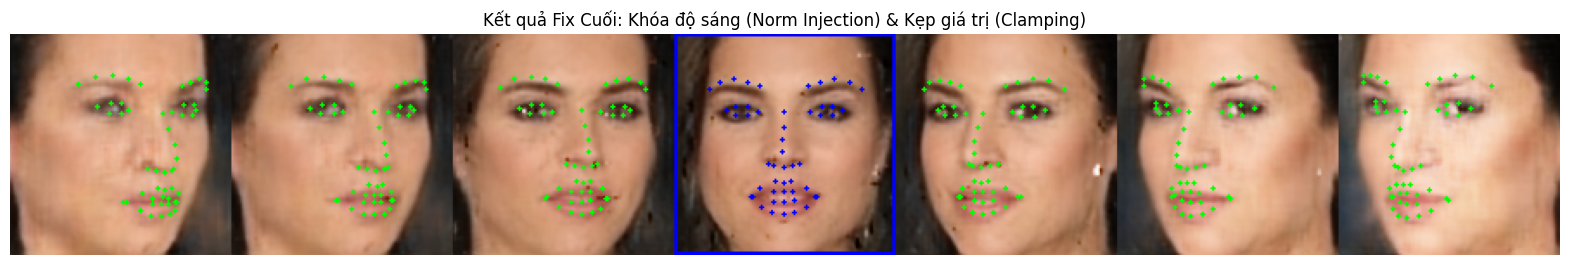

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
from google.colab import drive

# --- CẤU HÌNH ---
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
if not os.path.exists('/content/drive'): drive.mount('/content/drive')

PROJECT_DIR = "/content/drive/MyDrive/BEGAN_PROJECT"
Z_DATA_PATH = os.path.join(PROJECT_DIR, "inverse_results/z_dataset.npz")
REGRESSOR_PATH = os.path.join(PROJECT_DIR, "landmark_regressor_checkpoint.pth")
DECODER_PATH = os.path.join(PROJECT_DIR, "began_checkpoints/latest_checkpoint.pth")
Z_DIM = 64

# --- ĐỊNH NGHĨA CLASS (GIỮ NGUYÊN) ---
class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()
        self.fc = nn.Linear(Z_DIM, 8 * 8 * 64)
        self.layers = nn.Sequential(
            nn.Conv2d(64, 64, 3, 1, 1), nn.ELU(), nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 64, 3, 1, 1), nn.ELU(), nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 64, 3, 1, 1), nn.ELU(), nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 64, 3, 1, 1), nn.ELU(), nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 64, 3, 1, 1), nn.ELU(),
            nn.Conv2d(64, 3, 3, 1, 1), nn.Tanh()
        )
    def forward(self, x):
        x = self.fc(x)
        x = x.view(-1, 64, 8, 8)
        return self.layers(x)

class LandmarkRegressor(nn.Module):
    def __init__(self, output_dim):
        super(LandmarkRegressor, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(Z_DIM, 256), nn.BatchNorm1d(256), nn.LeakyReLU(0.2),
            nn.Linear(256, 256), nn.BatchNorm1d(256), nn.LeakyReLU(0.2),
            nn.Linear(256, output_dim)
        )
    def forward(self, x): return self.net(x)

# --- HÀM CHÍNH ĐÃ CẬP NHẬT ---
# ... (Giữ nguyên phần import và định nghĩa class Decoder, LandmarkRegressor, biến DEVICE, PATH...)

def run_final_rotation_fix():
    print("🚀 ĐANG CHẠY FIX CUỐI CÙNG (KHÓA ĐỘ SÁNG & KẸP GIÁ TRỊ)...")

    # 1. Load Regressor
    if not os.path.exists(REGRESSOR_PATH): return
    checkpoint = torch.load(REGRESSOR_PATH, map_location=DEVICE)
    num_points = checkpoint['num_points']
    regressor = LandmarkRegressor(checkpoint['output_dim']).to(DEVICE)
    regressor.load_state_dict(checkpoint['state_dict'])
    regressor.eval()

    # 2. Tính Vector Quay & Thống kê Dataset
    print("🧭 Đang phân tích thống kê dataset...")
    z_data = np.load(Z_DATA_PATH)
    z_all = torch.tensor(z_data['z_vectors'], dtype=torch.float32).to(DEVICE)

    # --- KỸ THUẬT MỚI 1: TÍNH THỐNG KÊ DATASET ---
    # Tìm giá trị trung bình độ lớn vector (Average Norm)
    norms = torch.norm(z_all, dim=1)
    avg_norm = torch.mean(norms).item()
    print(f"   -> Độ lớn trung bình (Avg Norm): {avg_norm:.4f}")

    # Tìm khoảng giá trị an toàn (Min/Max per dimension)
    z_min = torch.min(z_all, dim=0)[0]
    z_max = torch.max(z_all, dim=0)[0]

    # --- Logic tìm hướng quay (Giữ nguyên) ---
    with torch.no_grad():
        perm = torch.randperm(z_all.size(0))[:2000]
        z_sample = z_all[perm]
        pred_lms = regressor(z_sample).cpu().numpy().reshape(-1, num_points, 2)

    nose_idx = 13 if num_points < 60 else 30
    le_idx, re_idx = (19, 28) if num_points < 60 else (36, 45)

    left_idxs, right_idxs = [], []
    for i, pts in enumerate(pred_lms):
        yaw = np.linalg.norm(pts[nose_idx] - pts[re_idx]) - np.linalg.norm(pts[nose_idx] - pts[le_idx])
        if yaw > 0.05: right_idxs.append(i)
        elif yaw < -0.05: left_idxs.append(i)

    if not left_idxs: left_idxs = range(10)
    if not right_idxs: right_idxs = range(10, 20)

    z_left = torch.mean(z_sample[left_idxs], dim=0)
    z_right = torch.mean(z_sample[right_idxs], dim=0)
    rotation_vec = (z_right - z_left)
    rotation_vec = rotation_vec / torch.norm(rotation_vec)

    # 3. Load Decoder
    decoder = Decoder().to(DEVICE)
    ckpt = torch.load(DECODER_PATH, map_location=DEVICE)
    decoder.load_state_dict(ckpt['generator_state_dict'] if 'generator_state_dict' in ckpt else ckpt)
    decoder.eval()

    # 4. SINH ẢNH VỚI FIX MỚI
    rand_idx = np.random.randint(len(z_all))
    start_z = z_all[rand_idx].unsqueeze(0)

    # Biên độ quay (-3 đến 3)
    alphas = np.linspace(-3.0, 3.0, 7)
    output_imgs = []

    print("\n🎬 Đang sinh ảnh (Áp dụng Clamping & Norm Injection)...")
    with torch.no_grad():
        for alpha in alphas:
            # Bước 1: Cộng vector quay
            # (Nhân 4.5 thay vì 5.0 để giảm bớt lực quay cực đại)
            curr_z = start_z + (alpha * 4.5) * rotation_vec

            # --- KỸ THUẬT MỚI 2: DYNAMIC CLAMPING (KẸP GIÁ TRỊ) ---
            # Ép vector z không được vượt quá khoảng [min, max] của dataset gốc
            # Mở rộng khoảng min/max ra 1 chút (1.1) để cho phép biến đổi nhẹ
            curr_z = torch.max(torch.min(curr_z, z_max * 1.1), z_min * 1.1)

            # --- KỸ THUẬT MỚI 3: NORM INJECTION (ÉP ĐỘ LỚN CHUẨN) ---
            # Thay vì ép về độ lớn của ảnh gốc (có thể ảnh gốc bị tối/sáng bất thường)
            # Ta ép về độ lớn TRUNG BÌNH của cả tập dữ liệu -> Ổn định nhất
            curr_norm = torch.norm(curr_z)
            curr_z = curr_z * (avg_norm / curr_norm)

            # Sinh ảnh & Landmark
            img = decoder(curr_z)
            lms = regressor(curr_z).squeeze().cpu().numpy().reshape(num_points, 2) * 128.0

            # Xử lý hiển thị
            img_np = img.squeeze().cpu().permute(1, 2, 0).numpy()
            img_np = ((img_np + 1) / 2.0 * 255).astype(np.uint8).copy()
            img_np = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)

            # Màu landmark
            if abs(alpha) < 1e-2:
                lm_color = (255, 0, 0) # Blue (Gốc)
                cv2.rectangle(img_np, (0,0), (127,127), (255, 0, 0), 2)
            else:
                lm_color = (0, 255, 0) # Green (Xoay)

            for (x, y) in lms:
                cv2.circle(img_np, (int(x), int(y)), 1, lm_color, -1)

            output_imgs.append(cv2.cvtColor(img_np, cv2.COLOR_BGR2RGB))

    plt.figure(figsize=(20, 6))
    plt.axis('off')
    plt.title("Kết quả Fix Cuối: Khóa độ sáng (Norm Injection) & Kẹp giá trị (Clamping)")
    plt.imshow(np.hstack(output_imgs))
    plt.show()

if __name__ == "__main__":
    run_final_rotation_fix()

🚀 BẮT ĐẦU: LẤY MẪU Z ĐÃ TRAIN & ĐÁNH DẤU (BỎ VÙNG HÀM)...
✅ Đã load 202410 vector.
📸 Đang sinh ảnh...
🎨 Đang quét landmark (chỉ lấy mắt, mũi, miệng, lông mày)...


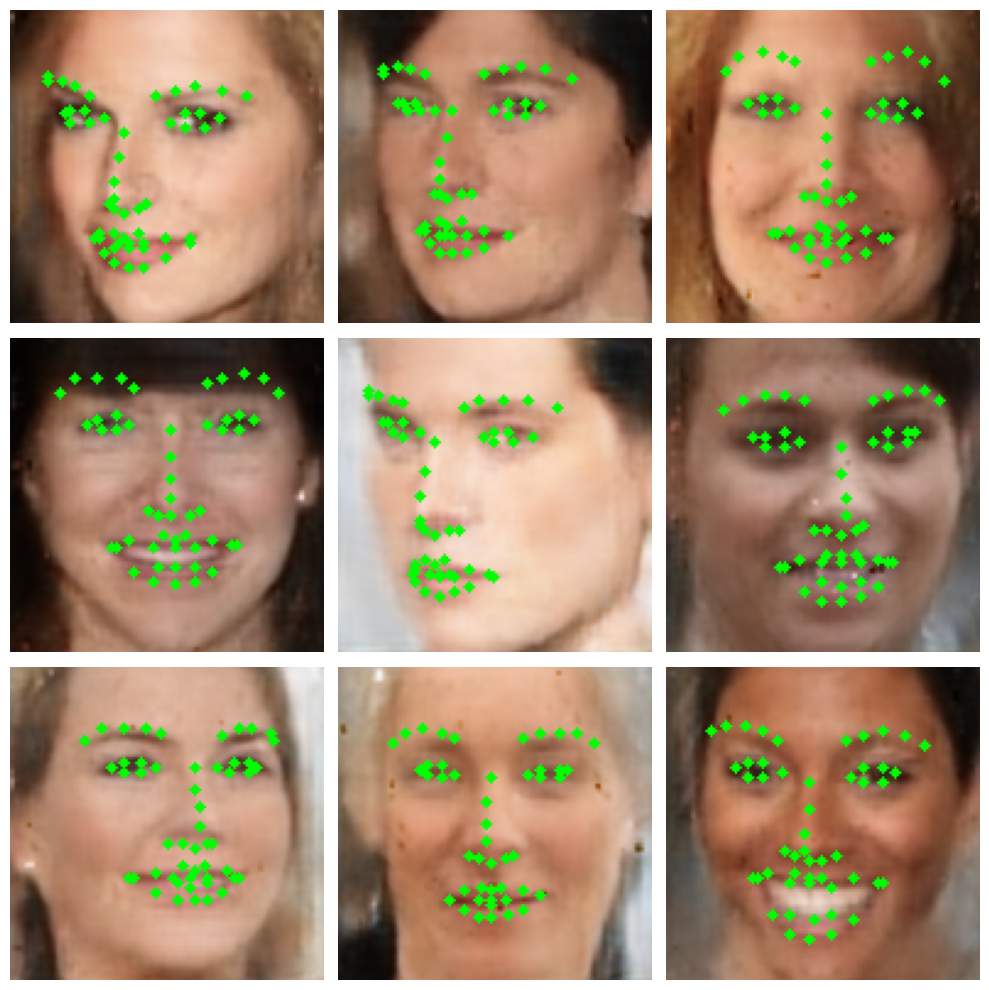

In [ ]:
# ==========================================
# 1. CÀI ĐẶT THƯ VIỆN
# ==========================================
try:
    import face_alignment
except ImportError:
    print("⏳ Đang cài đặt thư viện face-alignment...")
    !pip install face-alignment -q
    import face_alignment

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
from google.colab import drive

# ==========================================
# 2. CẤU HÌNH
# ==========================================
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

PROJECT_DIR = "/content/drive/MyDrive/BEGAN_PROJECT"
DECODER_PATH = os.path.join(PROJECT_DIR, "began_checkpoints/latest_checkpoint.pth")
Z_DATA_PATH = os.path.join(PROJECT_DIR, "inverse_results/z_dataset.npz")
Z_DIM = 64

# --- Định nghĩa Class Decoder ---
class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()
        self.fc = nn.Linear(Z_DIM, 8 * 8 * 64)
        self.layers = nn.Sequential(
            nn.Conv2d(64, 64, 3, 1, 1), nn.ELU(), nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 64, 3, 1, 1), nn.ELU(), nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 64, 3, 1, 1), nn.ELU(), nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 64, 3, 1, 1), nn.ELU(), nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 64, 3, 1, 1), nn.ELU(),
            nn.Conv2d(64, 3, 3, 1, 1), nn.Tanh()
        )
    def forward(self, x):
        x = self.fc(x)
        x = x.view(-1, 64, 8, 8)
        return self.layers(x)

# ==========================================
# 3. HÀM CHÍNH
# ==========================================
def sample_and_mark_faces_no_jaw():
    print("🚀 BẮT ĐẦU: LẤY MẪU Z ĐÃ TRAIN & ĐÁNH DẤU (BỎ VÙNG HÀM)...")

    # 1. Load Decoder
    decoder = Decoder().to(DEVICE)
    try:
        ckpt = torch.load(DECODER_PATH, map_location=DEVICE)
        decoder.load_state_dict(ckpt['generator_state_dict'] if 'generator_state_dict' in ckpt else ckpt)
        decoder.eval()
    except Exception as e:
        print(f"❌ Lỗi load Decoder: {e}")
        return

    # 2. Load Z Dataset
    if not os.path.exists(Z_DATA_PATH):
        print(f"❌ Không tìm thấy file Z dataset: {Z_DATA_PATH}")
        return

    z_data_npz = np.load(Z_DATA_PATH)
    z_vectors_all = z_data_npz['z_vectors']
    total_samples = len(z_vectors_all)
    print(f"✅ Đã load {total_samples} vector.")

    # 3. Lấy ngẫu nhiên 9 mẫu
    num_images = 9
    random_indices = np.random.choice(total_samples, num_images, replace=False)
    z_sampled_tensor = torch.tensor(z_vectors_all[random_indices], dtype=torch.float32).to(DEVICE)

    # 4. Khởi tạo Face Alignment
    try:
        landmark_type = face_alignment.LandmarksType.TWO_D
    except AttributeError:
        landmark_type = face_alignment.LandmarksType._2D
    fa = face_alignment.FaceAlignment(landmark_type, device=DEVICE, flip_input=False)

    # 5. Sinh ảnh
    print("📸 Đang sinh ảnh...")
    with torch.no_grad():
        generated_imgs = decoder(z_sampled_tensor)
        generated_imgs = torch.clamp(generated_imgs, -1, 1) # Fix lỗi tràn màu

    # 6. Xử lý và Vẽ Landmark
    output_imgs = []
    print("🎨 Đang quét landmark (chỉ lấy mắt, mũi, miệng, lông mày)...")

    imgs_np = generated_imgs.cpu().permute(0, 2, 3, 1).detach().numpy()
    imgs_np = ((imgs_np + 1) / 2.0 * 255).astype(np.uint8)

    for i in range(num_images):
        img_bgr = cv2.cvtColor(imgs_np[i], cv2.COLOR_RGB2BGR)
        img_rgb_input = imgs_np[i]

        try:
            preds = fa.get_landmarks(img_rgb_input)
            if preds:
                points = preds[0]

                # --- [THAY ĐỔI TẠI ĐÂY] ---
                # Chỉ lấy từ điểm thứ 17 trở đi (points[17:])
                # Bỏ qua 0-16 (Jawline)
                internal_features = points[17:]

                for p in internal_features:
                    x, y = int(p[0]), int(p[1])
                    cv2.circle(img_bgr, (x, y), 2, (0, 255, 0), -1)
            else:
                cv2.rectangle(img_bgr, (0,0), (127,127), (0, 0, 255), 2)
        except: pass

        output_imgs.append(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))

    # 7. Hiển thị
    fig, axes = plt.subplots(3, 3, figsize=(10, 10))
    for i, ax in enumerate(axes.flat):
        if i < len(output_imgs):
            ax.imshow(output_imgs[i])
            ax.axis('off')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    sample_and_mark_faces_no_jaw()

🚀 ĐANG CHẠY BÀI TEST ĐỐI CHIẾU 4 HÀNG...
🧭 Đang tính toán hướng quay...
🎬 Đang sinh chuỗi ảnh và dự đoán landmark...
🎨 Đang vẽ 4 chuỗi so sánh...


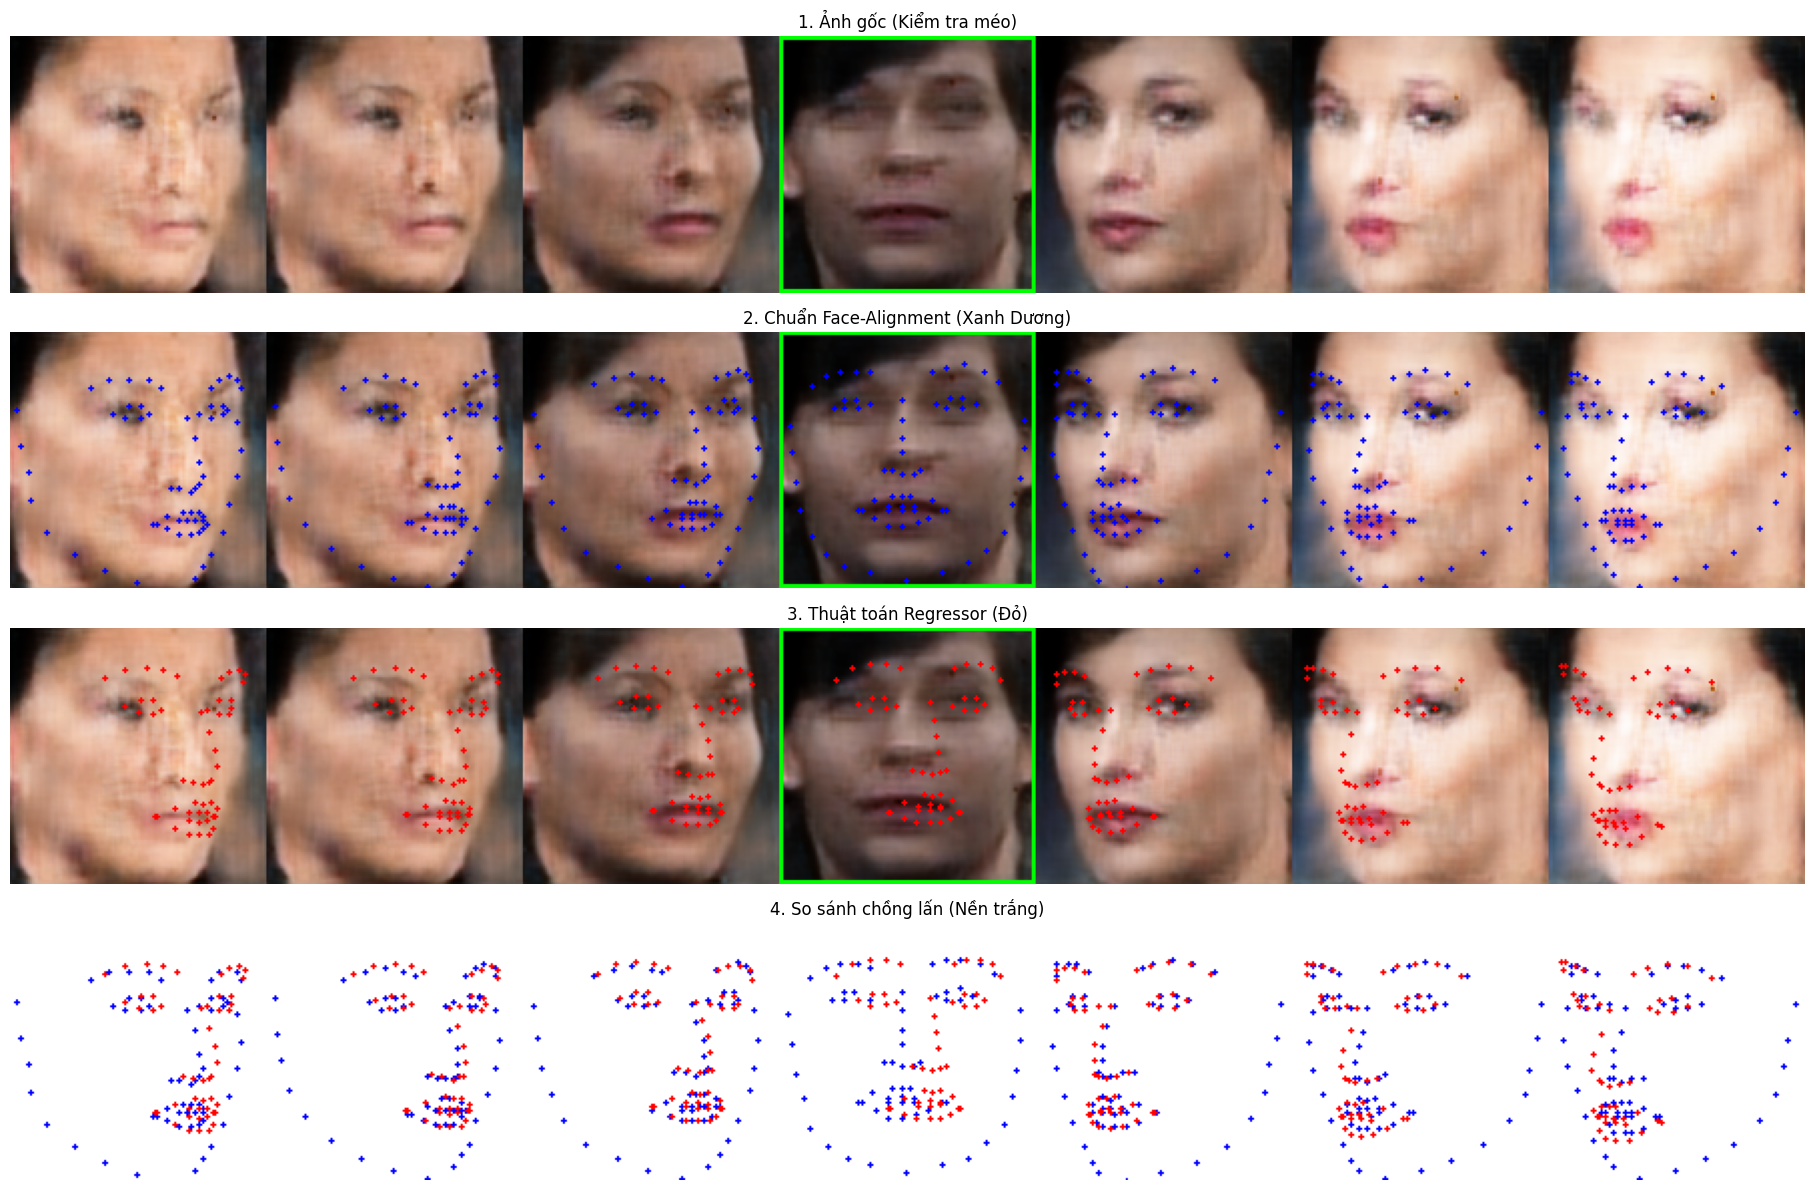

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
from google.colab import drive

# --- CẤU HÌNH & IMPORT FACE ALIGNMENT ---
try:
    import face_alignment
except ImportError:
    print("⏳ Đang cài đặt face-alignment...")
    !pip install face-alignment -q
    import face_alignment

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
if not os.path.exists('/content/drive'): drive.mount('/content/drive')

PROJECT_DIR = "/content/drive/MyDrive/BEGAN_PROJECT"
Z_DATA_PATH = os.path.join(PROJECT_DIR, "inverse_results/z_dataset.npz")
REGRESSOR_PATH = os.path.join(PROJECT_DIR, "landmark_regressor_checkpoint.pth")
DECODER_PATH = os.path.join(PROJECT_DIR, "began_checkpoints/latest_checkpoint.pth")
Z_DIM = 64

# --- ĐỊNH NGHĨA CLASS (GIỮ NGUYÊN) ---
class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()
        self.fc = nn.Linear(Z_DIM, 8 * 8 * 64)
        self.layers = nn.Sequential(
            nn.Conv2d(64, 64, 3, 1, 1), nn.ELU(), nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 64, 3, 1, 1), nn.ELU(), nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 64, 3, 1, 1), nn.ELU(), nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 64, 3, 1, 1), nn.ELU(), nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 64, 3, 1, 1), nn.ELU(),
            nn.Conv2d(64, 3, 3, 1, 1), nn.Tanh()
        )
    def forward(self, x):
        x = self.fc(x)
        x = x.view(-1, 64, 8, 8)
        return self.layers(x)

class LandmarkRegressor(nn.Module):
    def __init__(self, output_dim):
        super(LandmarkRegressor, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(Z_DIM, 256), nn.BatchNorm1d(256), nn.LeakyReLU(0.2),
            nn.Linear(256, 256), nn.BatchNorm1d(256), nn.LeakyReLU(0.2),
            nn.Linear(256, output_dim)
        )
    def forward(self, x): return self.net(x)

# --- HÀM CHẠY SO SÁNH 4 HÀNG ---
def run_comparison_test():
    print("🚀 ĐANG CHẠY BÀI TEST ĐỐI CHIẾU 4 HÀNG...")

    # 1. Load Models & Data
    if not os.path.exists(REGRESSOR_PATH):
        print(f"❌ Thiếu file: {REGRESSOR_PATH}"); return

    # Load Regressor
    ckpt_reg = torch.load(REGRESSOR_PATH, map_location=DEVICE)
    num_points = ckpt_reg['num_points']
    regressor = LandmarkRegressor(ckpt_reg['output_dim']).to(DEVICE)
    regressor.load_state_dict(ckpt_reg['state_dict'])
    regressor.eval()

    # Load Decoder
    decoder = Decoder().to(DEVICE)
    ckpt_dec = torch.load(DECODER_PATH, map_location=DEVICE)
    decoder.load_state_dict(ckpt_dec['generator_state_dict'] if 'generator_state_dict' in ckpt_dec else ckpt_dec)
    decoder.eval()

    # Load Z Data & Stats
    z_data = np.load(Z_DATA_PATH)
    z_all = torch.tensor(z_data['z_vectors'], dtype=torch.float32).to(DEVICE)

    # Tính thống kê (Avg Norm, Min, Max) để fix lỗi ảnh
    avg_norm = torch.mean(torch.norm(z_all, dim=1)).item()
    z_min = torch.min(z_all, dim=0)[0]
    z_max = torch.max(z_all, dim=0)[0]

    # 2. Tính Vector Quay (Giữ nguyên logic cũ)
    print("🧭 Đang tính toán hướng quay...")
    with torch.no_grad():
        perm = torch.randperm(z_all.size(0))[:2000]
        z_sample = z_all[perm]
        pred_lms = regressor(z_sample).cpu().numpy().reshape(-1, num_points, 2)

    nose_idx = 13 if num_points < 60 else 30
    le_idx, re_idx = (19, 28) if num_points < 60 else (36, 45)

    left_idxs = [i for i, pts in enumerate(pred_lms) if (np.linalg.norm(pts[nose_idx]-pts[re_idx]) - np.linalg.norm(pts[nose_idx]-pts[le_idx])) < -0.05]
    right_idxs = [i for i, pts in enumerate(pred_lms) if (np.linalg.norm(pts[nose_idx]-pts[re_idx]) - np.linalg.norm(pts[nose_idx]-pts[le_idx])) > 0.05]

    if not left_idxs: left_idxs = range(10)
    if not right_idxs: right_idxs = range(10, 20)

    z_left = torch.mean(z_sample[left_idxs], dim=0)
    z_right = torch.mean(z_sample[right_idxs], dim=0)
    rotation_vec = (z_right - z_left) / torch.norm(z_right - z_left)

    # 3. Chuẩn bị Face Alignment
    try: lm_type = face_alignment.LandmarksType.TWO_D
    except: lm_type = face_alignment.LandmarksType._2D
    fa = face_alignment.FaceAlignment(lm_type, device=DEVICE, flip_input=False)

    # 4. SINH DỮ LIỆU ẢNH (Chưa vẽ vội)
    rand_idx = np.random.randint(len(z_all))
    start_z = z_all[rand_idx].unsqueeze(0)
    alphas = np.linspace(-3.0, 3.0, 7) # 7 ảnh trong chuỗi

    generated_data = [] # Lưu (ảnh_gốc, landmark_regressor, is_origin)

    print("🎬 Đang sinh chuỗi ảnh và dự đoán landmark...")
    with torch.no_grad():
        for alpha in alphas:
            # Logic tính toán vector (Fix lỗi cháy sáng)
            curr_z = start_z + (alpha * 4.5) * rotation_vec
            curr_z = torch.max(torch.min(curr_z, z_max * 1.1), z_min * 1.1) # Clamping
            curr_norm = torch.norm(curr_z)
            curr_z = curr_z * (avg_norm / curr_norm) # Norm Injection

            # Sinh ảnh
            img_tensor = decoder(curr_z)
            # Sinh landmark bằng Regressor
            lms_reg = regressor(curr_z).squeeze().cpu().numpy().reshape(num_points, 2) * 128.0

            # Chuyển ảnh sang numpy (H, W, 3) BGR để vẽ
            img_np = img_tensor.squeeze().cpu().permute(1, 2, 0).numpy()
            img_np = ((img_np + 1) / 2.0 * 255).astype(np.uint8).copy()
            img_bgr = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)

            is_origin = abs(alpha) < 1e-2 # Đánh dấu ảnh gốc
            generated_data.append((img_bgr, lms_reg, is_origin))

    # 5. XỬ LÝ HẬU KỲ (TẠO 4 CHUỖI ẢNH)
    row1_imgs, row2_imgs, row3_imgs, row4_imgs = [], [], [], []

    print("🎨 Đang vẽ 4 chuỗi so sánh...")
    for (img_bgr, lms_reg, is_origin) in generated_data:

        # --- CHUẨN BỊ MÀU SẮC & KHUNG ---
        # OpenCV dùng BGR: Blue=(255,0,0), Red=(0,0,255), Green=(0,255,0)
        COLOR_FA = (255, 0, 0)   # Xanh Dương
        COLOR_REG = (0, 0, 255)  # Đỏ
        COLOR_BORDER = (0, 255, 0) # Xanh lá (Khung ảnh gốc)

        # --- ROW 1: ẢNH SẠCH (Chỉ có khung) ---
        r1 = img_bgr.copy()
        if is_origin: cv2.rectangle(r1, (0,0), (127,127), COLOR_BORDER, 2)
        row1_imgs.append(cv2.cvtColor(r1, cv2.COLOR_BGR2RGB))

        # --- ROW 2: FACE ALIGNMENT (XANH DƯƠNG) ---
        r2 = img_bgr.copy()
        if is_origin: cv2.rectangle(r2, (0,0), (127,127), COLOR_BORDER, 2)
        try:
            # Face alignment cần RGB input
            preds = fa.get_landmarks(cv2.cvtColor(r2, cv2.COLOR_BGR2RGB))
            if preds:
                # Lấy từ điểm 17 trở đi để bỏ hàm (nếu muốn giống Regressor)
                # Hoặc lấy hết. Ở đây tôi lấy hết để làm chuẩn.
                for p in preds[0]:
                    cv2.circle(r2, (int(p[0]), int(p[1])), 1, COLOR_FA, -1)
        except: pass
        row2_imgs.append(cv2.cvtColor(r2, cv2.COLOR_BGR2RGB))

        # --- ROW 3: REGRESSOR (ĐỎ) ---
        r3 = img_bgr.copy()
        if is_origin: cv2.rectangle(r3, (0,0), (127,127), COLOR_BORDER, 2)
        for (x, y) in lms_reg:
            cv2.circle(r3, (int(x), int(y)), 1, COLOR_REG, -1)
        row3_imgs.append(cv2.cvtColor(r3, cv2.COLOR_BGR2RGB))

        # --- ROW 4: SO SÁNH (NỀN TRẮNG + CẢ 2) ---
        # Tạo nền trắng 128x128
        r4 = np.ones_like(img_bgr) * 255

        # Vẽ điểm FA (Xanh Dương)
        try:
            preds = fa.get_landmarks(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
            if preds:
                for p in preds[0]:
                    cv2.circle(r4, (int(p[0]), int(p[1])), 1, COLOR_FA, -1)
        except: pass

        # Vẽ điểm Regressor (Đỏ)
        for (x, y) in lms_reg:
            cv2.circle(r4, (int(x), int(y)), 1, COLOR_REG, -1)

        row4_imgs.append(cv2.cvtColor(r4, cv2.COLOR_BGR2RGB))

    # 6. HIỂN THỊ
    # Ghép ngang từng hàng
    strip1 = np.hstack(row1_imgs)
    strip2 = np.hstack(row2_imgs)
    strip3 = np.hstack(row3_imgs)
    strip4 = np.hstack(row4_imgs)

    plt.figure(figsize=(20, 12))

    plt.subplot(4, 1, 1)
    plt.imshow(strip1); plt.axis('off'); plt.title("1. Ảnh gốc (Kiểm tra méo)")

    plt.subplot(4, 1, 2)
    plt.imshow(strip2); plt.axis('off'); plt.title("2. Chuẩn Face-Alignment (Xanh Dương)")

    plt.subplot(4, 1, 3)
    plt.imshow(strip3); plt.axis('off'); plt.title("3. Thuật toán Regressor (Đỏ)")

    plt.subplot(4, 1, 4)
    plt.imshow(strip4); plt.axis('off'); plt.title("4. So sánh chồng lấn (Nền trắng)")

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_comparison_test()

🚀 ĐANG CHẠY TEST SO SÁNH (CÓ TÍNH SAI SỐ)...
🧭 Đang tính toán hướng quay...
🎬 Đang sinh chuỗi ảnh...
🎨 Đang xử lý và tính sai số...


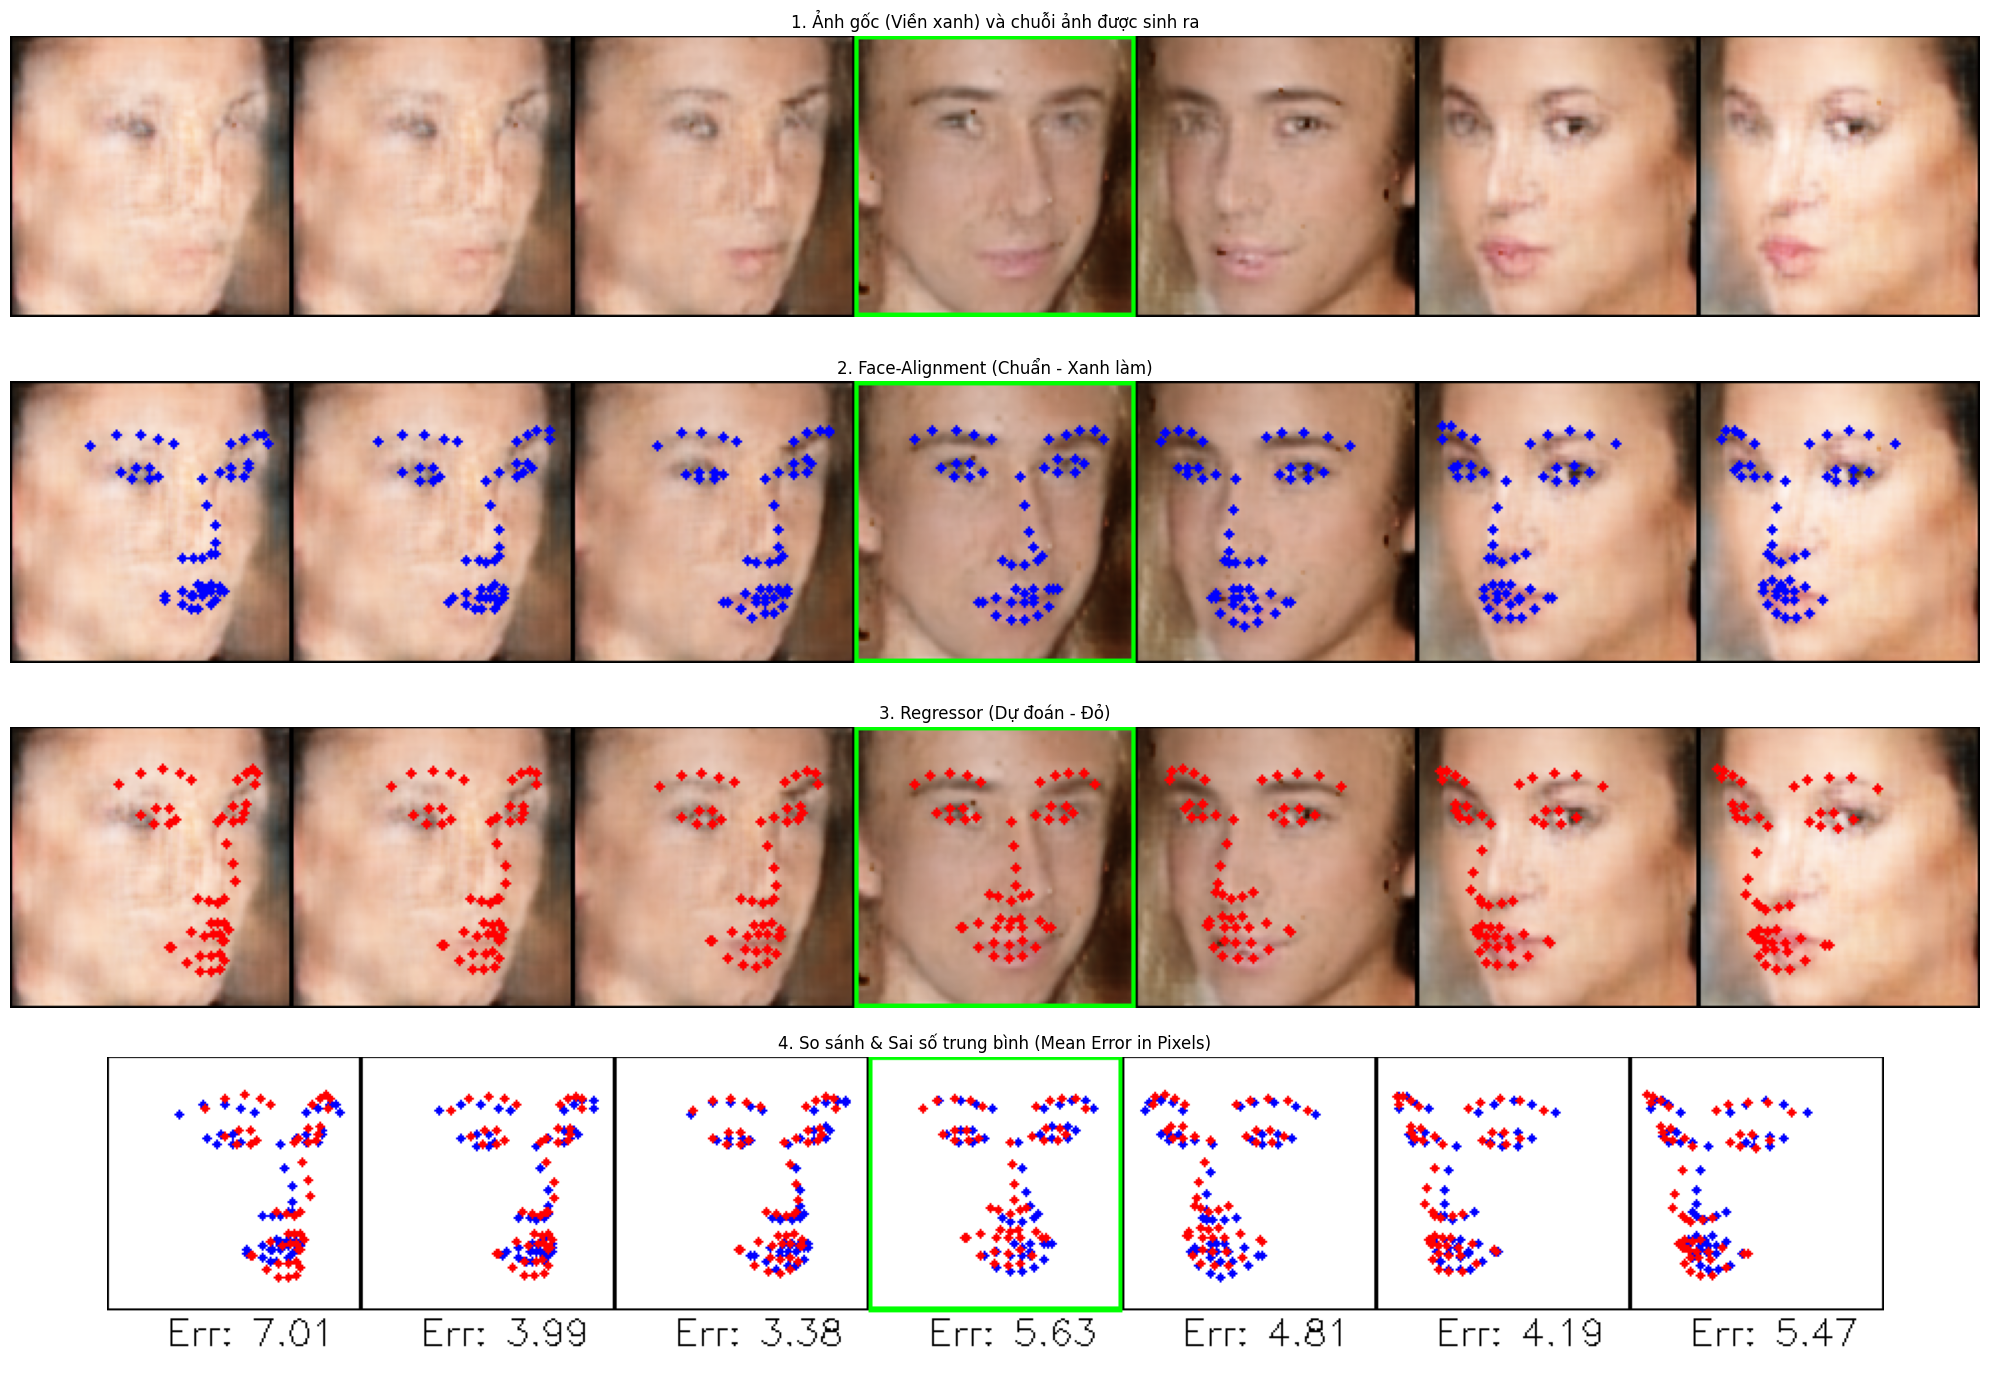

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
from google.colab import drive

# --- CẤU HÌNH & IMPORT ---
try:
    import face_alignment
except ImportError:
    print("⏳ Đang cài đặt face-alignment...")
    !pip install face-alignment -q
    import face_alignment

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
if not os.path.exists('/content/drive'): drive.mount('/content/drive')

PROJECT_DIR = "/content/drive/MyDrive/BEGAN_PROJECT"
Z_DATA_PATH = os.path.join(PROJECT_DIR, "inverse_results/z_dataset.npz")
REGRESSOR_PATH = os.path.join(PROJECT_DIR, "landmark_regressor_checkpoint.pth")
DECODER_PATH = os.path.join(PROJECT_DIR, "began_checkpoints/latest_checkpoint.pth")
Z_DIM = 64

# --- ĐỊNH NGHĨA CLASS ---
class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()
        self.fc = nn.Linear(Z_DIM, 8 * 8 * 64)
        self.layers = nn.Sequential(
            nn.Conv2d(64, 64, 3, 1, 1), nn.ELU(), nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 64, 3, 1, 1), nn.ELU(), nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 64, 3, 1, 1), nn.ELU(), nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 64, 3, 1, 1), nn.ELU(), nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 64, 3, 1, 1), nn.ELU(),
            nn.Conv2d(64, 3, 3, 1, 1), nn.Tanh()
        )
    def forward(self, x):
        x = self.fc(x)
        x = x.view(-1, 64, 8, 8)
        return self.layers(x)

class LandmarkRegressor(nn.Module):
    def __init__(self, output_dim):
        super(LandmarkRegressor, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(Z_DIM, 256), nn.BatchNorm1d(256), nn.LeakyReLU(0.2),
            nn.Linear(256, 256), nn.BatchNorm1d(256), nn.LeakyReLU(0.2),
            nn.Linear(256, output_dim)
        )
    def forward(self, x): return self.net(x)

# --- HÀM CHÍNH ---
def run_final_comparison_metric():
    print("🚀 ĐANG CHẠY TEST SO SÁNH (CÓ TÍNH SAI SỐ)...")

    # 1. Load Models & Data
    if not os.path.exists(REGRESSOR_PATH):
        print(f"❌ Thiếu file: {REGRESSOR_PATH}"); return

    # Load Regressor
    ckpt_reg = torch.load(REGRESSOR_PATH, map_location=DEVICE)
    num_points = ckpt_reg['num_points'] # Thường là 51 điểm
    regressor = LandmarkRegressor(ckpt_reg['output_dim']).to(DEVICE)
    regressor.load_state_dict(ckpt_reg['state_dict'])
    regressor.eval()

    # Load Decoder
    decoder = Decoder().to(DEVICE)
    ckpt_dec = torch.load(DECODER_PATH, map_location=DEVICE)
    decoder.load_state_dict(ckpt_dec['generator_state_dict'] if 'generator_state_dict' in ckpt_dec else ckpt_dec)
    decoder.eval()

    # Load Z Data
    z_data = np.load(Z_DATA_PATH)
    z_all = torch.tensor(z_data['z_vectors'], dtype=torch.float32).to(DEVICE)
    avg_norm = torch.mean(torch.norm(z_all, dim=1)).item()
    z_min = torch.min(z_all, dim=0)[0]
    z_max = torch.max(z_all, dim=0)[0]

    # 2. Tính Vector Quay
    print("🧭 Đang tính toán hướng quay...")
    with torch.no_grad():
        perm = torch.randperm(z_all.size(0))[:2000]
        z_sample = z_all[perm]
        pred_lms = regressor(z_sample).cpu().numpy().reshape(-1, num_points, 2)

    nose_idx = 13 if num_points < 60 else 30
    le_idx, re_idx = (19, 28) if num_points < 60 else (36, 45)

    left_idxs = [i for i, pts in enumerate(pred_lms) if (np.linalg.norm(pts[nose_idx]-pts[re_idx]) - np.linalg.norm(pts[nose_idx]-pts[le_idx])) < -0.05]
    right_idxs = [i for i, pts in enumerate(pred_lms) if (np.linalg.norm(pts[nose_idx]-pts[re_idx]) - np.linalg.norm(pts[nose_idx]-pts[le_idx])) > 0.05]

    if not left_idxs: left_idxs = range(10)
    if not right_idxs: right_idxs = range(10, 20)

    z_left = torch.mean(z_sample[left_idxs], dim=0)
    z_right = torch.mean(z_sample[right_idxs], dim=0)
    rotation_vec = (z_right - z_left) / torch.norm(z_right - z_left)

    # 3. Chuẩn bị Face Alignment
    try: lm_type = face_alignment.LandmarksType.TWO_D
    except: lm_type = face_alignment.LandmarksType._2D
    fa = face_alignment.FaceAlignment(lm_type, device=DEVICE, flip_input=False)

    # 4. SINH DỮ LIỆU ẢNH
    rand_idx = np.random.randint(len(z_all))
    start_z = z_all[rand_idx].unsqueeze(0)
    alphas = np.linspace(-3.0, 3.0, 7)

    generated_data = []

    print("🎬 Đang sinh chuỗi ảnh...")
    with torch.no_grad():
        for alpha in alphas:
            curr_z = start_z + (alpha * 4.5) * rotation_vec
            curr_z = torch.max(torch.min(curr_z, z_max * 1.1), z_min * 1.1)
            curr_norm = torch.norm(curr_z)
            curr_z = curr_z * (avg_norm / curr_norm)

            img_tensor = decoder(curr_z)
            # Regressor Landmark (dự đoán)
            lms_reg = regressor(curr_z).squeeze().cpu().numpy().reshape(num_points, 2) * 128.0

            img_np = img_tensor.squeeze().cpu().permute(1, 2, 0).numpy()
            img_np = ((img_np + 1) / 2.0 * 255).astype(np.uint8).copy()
            img_bgr = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)

            is_origin = abs(alpha) < 1e-2
            generated_data.append((img_bgr, lms_reg, is_origin))

    # 5. XỬ LÝ HẬU KỲ & VẼ
    row1_imgs, row2_imgs, row3_imgs, row4_imgs = [], [], [], []

    print("🎨 Đang xử lý và tính sai số...")
    for (img_bgr, lms_reg, is_origin) in generated_data:

        # --- MÀU SẮC ---
        COLOR_FA = (255, 0, 0)     # Xanh Dương
        COLOR_REG = (0, 0, 255)    # Đỏ
        COLOR_BORDER_ORIGIN = (0, 255, 0) # Xanh lá (Khung gốc)
        COLOR_BORDER_ALL = (0, 0, 0)      # Đen (Viền mảnh)

        # Helper: Hàm thêm viền
        def add_borders(img, is_orig):
            # 1. Viền đen mảnh toàn bộ (1px)
            cv2.rectangle(img, (0,0), (127,127), COLOR_BORDER_ALL, 1)
            # 2. Viền xanh lá nếu là ảnh gốc (2px)
            if is_orig:
                cv2.rectangle(img, (0,0), (127,127), COLOR_BORDER_ORIGIN, 2)
            return img

        # --- ROW 1: ẢNH SẠCH ---
        r1 = img_bgr.copy()
        r1 = add_borders(r1, is_origin)
        row1_imgs.append(cv2.cvtColor(r1, cv2.COLOR_BGR2RGB))

        # --- TÌM ĐIỂM FACE ALIGNMENT (LÀM CHUẨN) ---
        lms_fa_filtered = None # Để lưu điểm chuẩn sau khi lọc jawline

        try:
            preds = fa.get_landmarks(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
            if preds:
                # Lấy 68 điểm gốc
                raw_points = preds[0]
                # Lọc bỏ Jawline (Lấy từ index 17 trở đi) -> Còn 51 điểm
                lms_fa_filtered = raw_points[17:]
        except: pass

        # --- ROW 2: FACE ALIGNMENT (XANH DƯƠNG - NO JAWLINE) ---
        r2 = img_bgr.copy()
        if lms_fa_filtered is not None:
            for p in lms_fa_filtered:
                cv2.circle(r2, (int(p[0]), int(p[1])), 2, COLOR_FA, -1)
        r2 = add_borders(r2, is_origin)
        row2_imgs.append(cv2.cvtColor(r2, cv2.COLOR_BGR2RGB))

        # --- ROW 3: REGRESSOR (ĐỎ) ---
        r3 = img_bgr.copy()
        for (x, y) in lms_reg:
            cv2.circle(r3, (int(x), int(y)), 2, COLOR_REG, -1)
        r3 = add_borders(r3, is_origin)
        row3_imgs.append(cv2.cvtColor(r3, cv2.COLOR_BGR2RGB))

        # --- ROW 4: SO SÁNH & TÍNH SAI SỐ (NỀN TRẮNG) ---
        # Tạo nền trắng (thêm phần đệm bên dưới để ghi chữ)
        base_h, base_w = 128, 128
        pad_bottom = 30
        r4 = np.ones((base_h + pad_bottom, base_w, 3), dtype=np.uint8) * 255

        # Vẽ điểm FA (Xanh Dương)
        if lms_fa_filtered is not None:
            for p in lms_fa_filtered:
                cv2.circle(r4, (int(p[0]), int(p[1])), 2, COLOR_FA, -1)

        # Vẽ điểm Regressor (Đỏ)
        for (x, y) in lms_reg:
            cv2.circle(r4, (int(x), int(y)), 2, COLOR_REG, -1)

        # TÍNH TOÁN ĐỘ LỆCH (ERROR)
        error_text = "N/A"
        if lms_fa_filtered is not None:
            # Đảm bảo số lượng điểm khớp nhau để tính (thường là 51 điểm)
            # Regressor của bạn output 51 điểm. FA sau khi filter cũng 51 điểm.
            if len(lms_fa_filtered) == len(lms_reg):
                # Tính khoảng cách Euclidean trung bình (Mean Euclidean Distance)
                diff = lms_fa_filtered - lms_reg
                dist = np.linalg.norm(diff, axis=1) # Khoảng cách từng điểm
                mean_error = np.mean(dist) # Trung bình cộng
                error_text = f"Err: {mean_error:.2f}"
            else:
                error_text = "Dim Err" # Lệch số lượng điểm
        else:
            error_text = "No Face" # Face Alignment không tìm thấy mặt

        # Ghi chữ vào phần đệm trắng
        cv2.putText(r4, error_text, (30, 145), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,0), 1)

        # Thêm viền cho phần ảnh chính (128x128) bên trên
        cv2.rectangle(r4, (0,0), (127,127), COLOR_BORDER_ALL, 1)
        if is_origin:
            cv2.rectangle(r4, (0,0), (127,127), COLOR_BORDER_ORIGIN, 2)

        row4_imgs.append(cv2.cvtColor(r4, cv2.COLOR_BGR2RGB))

    # 6. HIỂN THỊ
    strip1 = np.hstack(row1_imgs)
    strip2 = np.hstack(row2_imgs)
    strip3 = np.hstack(row3_imgs)
    strip4 = np.hstack(row4_imgs)

    plt.figure(figsize=(20, 14)) # Tăng chiều cao để chứa phần chú thích

    plt.subplot(4, 1, 1)
    plt.imshow(strip1); plt.axis('off'); plt.title("1. Ảnh gốc (Viền xanh) và chuỗi ảnh được sinh ra")

    plt.subplot(4, 1, 2)
    plt.imshow(strip2); plt.axis('off'); plt.title("2. Face-Alignment (Chuẩn - Xanh làm)")

    plt.subplot(4, 1, 3)
    plt.imshow(strip3); plt.axis('off'); plt.title("3. Regressor (Dự đoán - Đỏ)")

    plt.subplot(4, 1, 4)
    plt.imshow(strip4); plt.axis('off'); plt.title("4. So sánh & Sai số trung bình (Mean Error in Pixels)")

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_final_comparison_metric()

💻 Thiết bị: cuda
📂 Đang tìm dữ liệu tại: /content/drive/MyDrive/BEGAN_PROJECT

🚀 ĐANG KHỞI CHẠY QUY TRÌNH KIỂM TRA...
   -> Loading Regressor...
   -> Loading Decoder...
   -> Loading Z Dataset...
   -> Initializing Face-Alignment...
📸 Đang xử lý 10 ảnh mẫu...
🎨 Đang vẽ bảng so sánh...


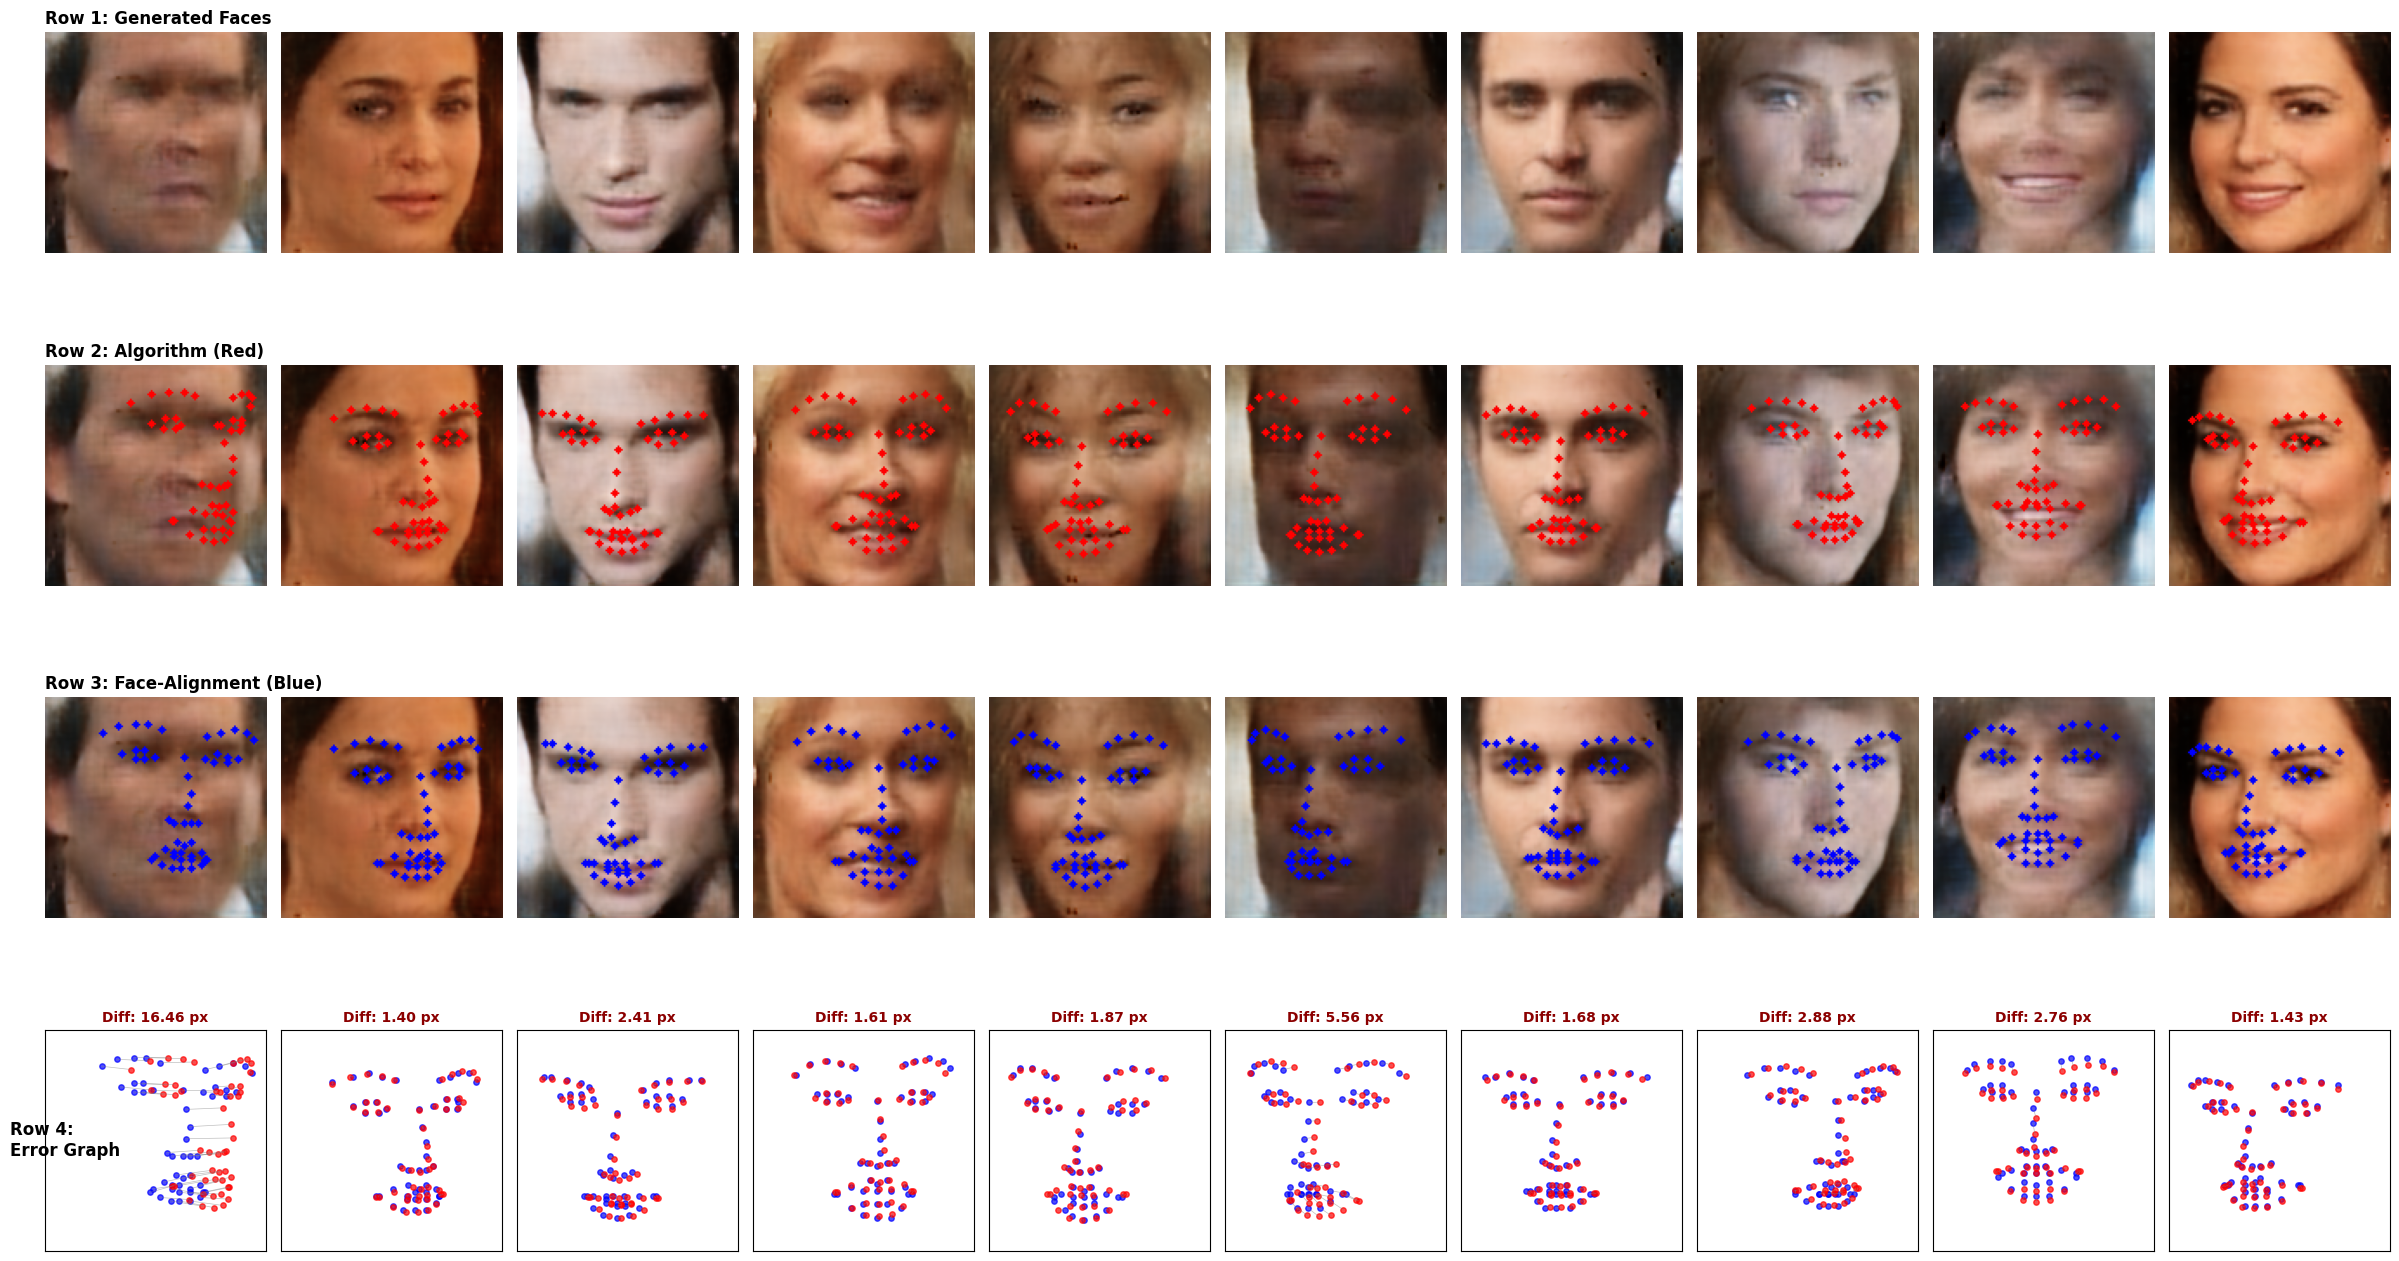

✅ HOÀN TẤT.


In [4]:
# ==============================================================================
# BƯỚC 1: CÀI ĐẶT MÔI TRƯỜNG & KHAI BÁO ĐƯỜNG DẪN
# ==============================================================================
import os
import sys

# 1. Cài đặt thư viện face-alignment (nếu chưa có)
try:
    import face_alignment
except ImportError:
    print("⏳ Đang cài đặt thư viện face-alignment...")
    !pip install face-alignment -q
    import face_alignment

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import cv2
from google.colab import drive

# 2. Mount Google Drive
if not os.path.exists('/content/drive'):
    print("info: Đang kết nối Google Drive...")
    drive.mount('/content/drive')

# 3. CẤU HÌNH ĐƯỜNG DẪN (QUAN TRỌNG: Kiểm tra lại tên thư mục của bạn)
# Hãy sửa dòng dưới đây nếu thư mục của bạn tên khác
PROJECT_DIR = "/content/drive/MyDrive/BEGAN_PROJECT"

# Tự động tạo các đường dẫn con
Z_DATA_PATH = os.path.join(PROJECT_DIR, "inverse_results/z_dataset.npz")
REGRESSOR_PATH = os.path.join(PROJECT_DIR, "landmark_regressor_checkpoint.pth")
DECODER_PATH = os.path.join(PROJECT_DIR, "began_checkpoints/latest_checkpoint.pth")

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
Z_DIM = 64

print(f"💻 Thiết bị: {DEVICE}")
print(f"📂 Đang tìm dữ liệu tại: {PROJECT_DIR}")

# Kiểm tra file tồn tại chưa
if not os.path.exists(Z_DATA_PATH):
    print(f"❌ LỖI: Không tìm thấy file {Z_DATA_PATH}")
    print("   -> Bạn hãy kiểm tra lại đường dẫn PROJECT_DIR.")

# ==============================================================================
# BƯỚC 2: ĐỊNH NGHĨA MODEL (Decoder & Regressor)
# ==============================================================================
class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()
        self.fc = nn.Linear(Z_DIM, 8 * 8 * 64)
        self.layers = nn.Sequential(
            nn.Conv2d(64, 64, 3, 1, 1), nn.ELU(), nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 64, 3, 1, 1), nn.ELU(), nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 64, 3, 1, 1), nn.ELU(), nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 64, 3, 1, 1), nn.ELU(), nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 64, 3, 1, 1), nn.ELU(),
            nn.Conv2d(64, 3, 3, 1, 1), nn.Tanh()
        )
    def forward(self, x):
        x = self.fc(x)
        x = x.view(-1, 64, 8, 8)
        return self.layers(x)

class LandmarkRegressor(nn.Module):
    def __init__(self, output_dim):
        super(LandmarkRegressor, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(Z_DIM, 256), nn.BatchNorm1d(256), nn.LeakyReLU(0.2),
            nn.Linear(256, 256), nn.BatchNorm1d(256), nn.LeakyReLU(0.2),
            nn.Linear(256, output_dim)
        )
    def forward(self, x): return self.net(x)

# ==============================================================================
# BƯỚC 3: HÀM CHÍNH (XỬ LÝ VÀ VẼ 4 HÀNG)
# ==============================================================================
def run_full_benchmark():
    print("\n🚀 ĐANG KHỞI CHẠY QUY TRÌNH KIỂM TRA...")

    # A. LOAD MODELS
    # ---------------------------------------------------------
    if not os.path.exists(REGRESSOR_PATH) or not os.path.exists(DECODER_PATH):
        print("❌ Thiếu file model checkpoint (.pth). Kiểm tra lại đường dẫn!")
        return

    # Load Regressor
    print("   -> Loading Regressor...")
    ckpt_reg = torch.load(REGRESSOR_PATH, map_location=DEVICE)
    num_points_reg = ckpt_reg['num_points'] # 51 điểm
    regressor = LandmarkRegressor(ckpt_reg['output_dim']).to(DEVICE)
    regressor.load_state_dict(ckpt_reg['state_dict'])
    regressor.eval()

    # Load Decoder
    print("   -> Loading Decoder...")
    decoder = Decoder().to(DEVICE)
    ckpt_dec = torch.load(DECODER_PATH, map_location=DEVICE)
    decoder.load_state_dict(ckpt_dec['generator_state_dict'] if 'generator_state_dict' in ckpt_dec else ckpt_dec)
    decoder.eval()

    # Load Z Data
    print("   -> Loading Z Dataset...")
    z_data = np.load(Z_DATA_PATH)
    z_all = torch.tensor(z_data['z_vectors'], dtype=torch.float32).to(DEVICE)

    # Init Face Alignment
    print("   -> Initializing Face-Alignment...")
    try: lm_type = face_alignment.LandmarksType.TWO_D
    except: lm_type = face_alignment.LandmarksType._2D
    fa = face_alignment.FaceAlignment(lm_type, device=DEVICE, flip_input=False)

    # B. CHỌN 10 ẢNH NGẪU NHIÊN
    # ---------------------------------------------------------
    num_samples = 10
    rand_indices = np.random.choice(len(z_all), num_samples, replace=False)
    z_batch = z_all[rand_indices]

    # C. SINH DỮ LIỆU
    # ---------------------------------------------------------
    print(f"📸 Đang xử lý {num_samples} ảnh mẫu...")
    with torch.no_grad():
        # Sinh ảnh từ Decoder
        imgs_tensor = decoder(z_batch)
        # Dự đoán landmark từ Regressor (Màu Đỏ)
        lms_reg_batch = regressor(z_batch).cpu().numpy().reshape(num_samples, num_points_reg, 2) * 128.0

    # Chuyển ảnh sang Numpy (0-255)
    imgs_np = imgs_tensor.permute(0, 2, 3, 1).cpu().numpy()
    imgs_np = ((imgs_np + 1) / 2.0 * 255).astype(np.uint8)

    # D. VÒNG LẶP XỬ LÝ CHI TIẾT
    # ---------------------------------------------------------
    results = []
    for i in range(num_samples):
        img_bgr = cv2.cvtColor(imgs_np[i], cv2.COLOR_RGB2BGR)
        lms_reg = lms_reg_batch[i]

        # Dùng Face-Alignment để tìm Ground Truth (Màu Xanh)
        lms_fa = None
        try:
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            preds = fa.get_landmarks(img_rgb)
            if preds:
                # Lọc bỏ vùng hàm (0-16) -> Lấy từ 17 trở đi
                lms_fa = preds[0][17:]
        except: pass

        results.append({
            "img": img_bgr,
            "lms_reg": lms_reg,
            "lms_fa": lms_fa
        })

    # E. VẼ ĐỒ THỊ (4 HÀNG)
    # ---------------------------------------------------------
    print("🎨 Đang vẽ bảng so sánh...")
    fig, axes = plt.subplots(4, 10, figsize=(24, 14))

    # Định nghĩa màu (BGR cho OpenCV, tên màu cho Matplotlib)
    COLOR_REG_BGR = (0, 0, 255)   # Đỏ
    COLOR_FA_BGR = (255, 0, 0)    # Xanh Dương

    for col in range(10):
        data = results[col]
        img_base = data['img'].copy()

        # --- HÀNG 1: ẢNH GỐC ---
        ax1 = axes[0, col]
        ax1.imshow(cv2.cvtColor(img_base, cv2.COLOR_BGR2RGB))
        ax1.axis('off')
        if col == 0: ax1.set_title("Row 1: Generated Faces", loc='left', fontsize=12, fontweight='bold')

        # --- HÀNG 2: THUẬT TOÁN (CHẤM ĐỎ) ---
        img_reg = img_base.copy()
        for (x, y) in data['lms_reg']:
            cv2.circle(img_reg, (int(x), int(y)), 2, COLOR_REG_BGR, -1)

        ax2 = axes[1, col]
        ax2.imshow(cv2.cvtColor(img_reg, cv2.COLOR_BGR2RGB))
        ax2.axis('off')
        if col == 0: ax2.set_title("Row 2: Algorithm (Red)", loc='left', fontsize=12, fontweight='bold')

        # --- HÀNG 3: FACE ALIGNMENT (CHẤM XANH - NO JAW) ---
        img_fa = img_base.copy()
        valid_fa = False
        if data['lms_fa'] is not None:
            valid_fa = True
            for (x, y) in data['lms_fa']:
                cv2.circle(img_fa, (int(x), int(y)), 2, COLOR_FA_BGR, -1)

        ax3 = axes[2, col]
        ax3.imshow(cv2.cvtColor(img_fa, cv2.COLOR_BGR2RGB))
        ax3.axis('off')
        if col == 0: ax3.set_title("Row 3: Face-Alignment (Blue)", loc='left', fontsize=12, fontweight='bold')

        # --- HÀNG 4: ĐỒ THỊ SAI SỐ (SCATTER PLOT) ---
        ax4 = axes[3, col]

        # Chỉ vẽ nếu tìm thấy mặt bằng Face-Alignment và số điểm khớp nhau
        if valid_fa and len(data['lms_fa']) == len(data['lms_reg']):
            # Tính sai số trung bình (Mean Euclidean Distance)
            diff = data['lms_fa'] - data['lms_reg']
            mean_error = np.mean(np.linalg.norm(diff, axis=1))

            # Cấu hình trục đồ thị (0-128)
            ax4.invert_yaxis() # Đảo trục Y để khớp với hệ tọa độ ảnh
            ax4.set_xlim(0, 128)
            ax4.set_ylim(128, 0)
            ax4.set_aspect('equal')

            # Vẽ điểm
            ax4.scatter(data['lms_fa'][:, 0], data['lms_fa'][:, 1], c='blue', s=15, label='FA', alpha=0.7)
            ax4.scatter(data['lms_reg'][:, 0], data['lms_reg'][:, 1], c='red', s=15, label='Alg', alpha=0.7)

            # Vẽ đường nối (Residual Vectors)
            for k in range(len(data['lms_fa'])):
                x_pair = [data['lms_fa'][k, 0], data['lms_reg'][k, 0]]
                y_pair = [data['lms_fa'][k, 1], data['lms_reg'][k, 1]]
                ax4.plot(x_pair, y_pair, color='gray', linewidth=0.5, alpha=0.5)

            ax4.set_title(f"Diff: {mean_error:.2f} px", fontsize=10, color='darkred', fontweight='bold')
            ax4.set_xticks([])
            ax4.set_yticks([])
        else:
            ax4.text(64, 64, "No Detect", ha='center', va='center', color='gray')
            ax4.set_xlim(0, 128); ax4.set_ylim(128, 0)
            ax4.set_xticks([]); ax4.set_yticks([])

        if col == 0: ax4.text(-20, 64, "Row 4:\nError Graph", fontsize=12, fontweight='bold', va='center')

    plt.tight_layout()
    plt.show()
    print("✅ HOÀN TẤT.")

if __name__ == "__main__":
    run_full_benchmark()

🚀 Bắt đầu quy trình kiểm thử.
📂 Kết quả sẽ lưu tại: /content/drive/MyDrive/BEGAN_PROJECT/validation_results_20251219_173714
⏳ Đang load Models...
⏳ Khởi tạo Face-Alignment...

🚀 BẮT ĐẦU XỬ LÝ 10000 ẢNH...
   [Batch 1/40] Xử lý 256 ảnh trong 9.45s (0.037s/ảnh)
   [Batch 2/40] Xử lý 256 ảnh trong 7.06s (0.028s/ảnh)
   [Batch 3/40] Xử lý 256 ảnh trong 7.16s (0.028s/ảnh)
   [Batch 4/40] Xử lý 256 ảnh trong 7.02s (0.027s/ảnh)
   [Batch 5/40] Xử lý 256 ảnh trong 7.25s (0.028s/ảnh)
   [Batch 6/40] Xử lý 256 ảnh trong 7.05s (0.028s/ảnh)
   [Batch 7/40] Xử lý 256 ảnh trong 7.33s (0.029s/ảnh)
   [Batch 8/40] Xử lý 256 ảnh trong 7.18s (0.028s/ảnh)
   [Batch 9/40] Xử lý 256 ảnh trong 7.13s (0.028s/ảnh)
   [Batch 10/40] Xử lý 256 ảnh trong 7.44s (0.029s/ảnh)
   [Batch 11/40] Xử lý 256 ảnh trong 7.12s (0.028s/ảnh)
   [Batch 12/40] Xử lý 256 ảnh trong 7.16s (0.028s/ảnh)
   [Batch 13/40] Xử lý 256 ảnh trong 7.38s (0.029s/ảnh)
   [Batch 14/40] Xử lý 256 ảnh trong 7.26s (0.028s/ảnh)
   [Batch 15/40] Xử 

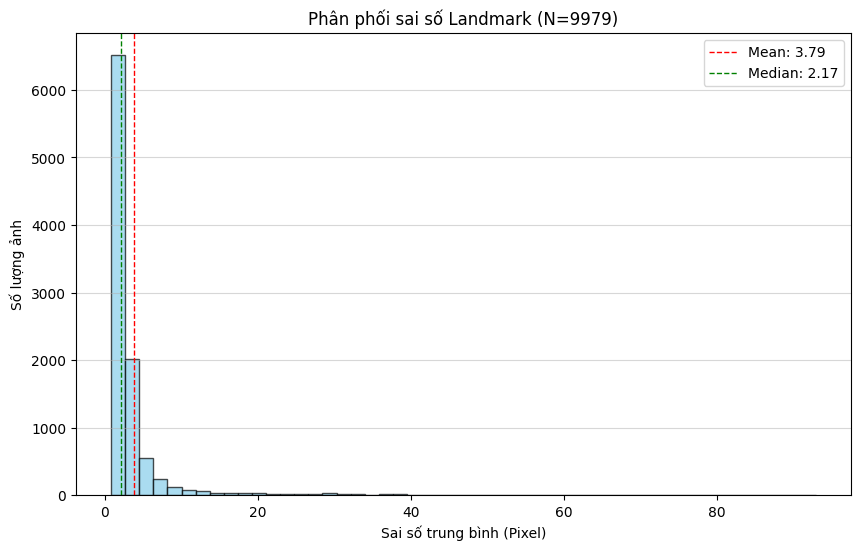

✅ HOÀN TẤT! Kiểm tra thư mục: /content/drive/MyDrive/BEGAN_PROJECT/validation_results_20251219_173714


In [5]:
# ==============================================================================
# BƯỚC 1: CÀI ĐẶT VÀ CẤU HÌNH
# ==============================================================================
import os
import time
from datetime import datetime
import csv

# Cài thư viện cần thiết
try:
    import face_alignment
except ImportError:
    print("⏳ Đang cài face-alignment...")
    !pip install face-alignment -q
    import face_alignment

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from google.colab import drive

# Mount Drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# Cấu hình đường dẫn
PROJECT_DIR = "/content/drive/MyDrive/BEGAN_PROJECT"
# Tạo thư mục chứa kết quả validation riêng biệt
TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
OUTPUT_DIR = os.path.join(PROJECT_DIR, f"validation_results_{TIMESTAMP}")
IMG_SAVE_DIR = os.path.join(OUTPUT_DIR, "generated_images")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(IMG_SAVE_DIR, exist_ok=True)

# Đường dẫn model (Kiểm tra lại nếu cần)
REGRESSOR_PATH = os.path.join(PROJECT_DIR, "landmark_regressor_checkpoint.pth")
DECODER_PATH = os.path.join(PROJECT_DIR, "began_checkpoints/latest_checkpoint.pth")
Z_DATA_PATH = os.path.join(PROJECT_DIR, "inverse_results/z_dataset.npz")

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
Z_DIM = 64
BATCH_SIZE = 256       # Xử lý 128 ảnh mỗi lần (Tăng lên nếu GPU mạnh)
TOTAL_IMAGES = 10000   # Tổng số ảnh cần test

print(f"🚀 Bắt đầu quy trình kiểm thử.")
print(f"📂 Kết quả sẽ lưu tại: {OUTPUT_DIR}")

# ==============================================================================
# BƯỚC 2: ĐỊNH NGHĨA MODEL
# ==============================================================================
class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()
        self.fc = nn.Linear(Z_DIM, 8 * 8 * 64)
        self.layers = nn.Sequential(
            nn.Conv2d(64, 64, 3, 1, 1), nn.ELU(), nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 64, 3, 1, 1), nn.ELU(), nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 64, 3, 1, 1), nn.ELU(), nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 64, 3, 1, 1), nn.ELU(), nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 64, 3, 1, 1), nn.ELU(),
            nn.Conv2d(64, 3, 3, 1, 1), nn.Tanh()
        )
    def forward(self, x):
        x = self.fc(x)
        x = x.view(-1, 64, 8, 8)
        return self.layers(x)

class LandmarkRegressor(nn.Module):
    def __init__(self, output_dim):
        super(LandmarkRegressor, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(Z_DIM, 256), nn.BatchNorm1d(256), nn.LeakyReLU(0.2),
            nn.Linear(256, 256), nn.BatchNorm1d(256), nn.LeakyReLU(0.2),
            nn.Linear(256, output_dim)
        )
    def forward(self, x): return self.net(x)

# ==============================================================================
# BƯỚC 3: HÀM XỬ LÝ CHÍNH
# ==============================================================================
def run_massive_validation():
    # 1. LOAD MODEL
    print("⏳ Đang load Models...")
    if not os.path.exists(REGRESSOR_PATH): print("❌ Thiếu Regressor"); return

    # Load Regressor
    ckpt_reg = torch.load(REGRESSOR_PATH, map_location=DEVICE)
    num_points = ckpt_reg['num_points'] # 51 điểm
    regressor = LandmarkRegressor(ckpt_reg['output_dim']).to(DEVICE)
    regressor.load_state_dict(ckpt_reg['state_dict'])
    regressor.eval()

    # Load Decoder
    decoder = Decoder().to(DEVICE)
    ckpt_dec = torch.load(DECODER_PATH, map_location=DEVICE)
    decoder.load_state_dict(ckpt_dec['generator_state_dict'] if 'generator_state_dict' in ckpt_dec else ckpt_dec)
    decoder.eval()

    # Load Z Dataset (để lấy thống kê Norm)
    z_data = np.load(Z_DATA_PATH)
    z_all_ref = torch.tensor(z_data['z_vectors'], dtype=torch.float32).to(DEVICE)
    avg_norm = torch.mean(torch.norm(z_all_ref, dim=1)).item()
    z_min = torch.min(z_all_ref, dim=0)[0]
    z_max = torch.max(z_all_ref, dim=0)[0]

    # Init Face Alignment
    print("⏳ Khởi tạo Face-Alignment...")
    try: lm_type = face_alignment.LandmarksType.TWO_D
    except: lm_type = face_alignment.LandmarksType._2D
    fa = face_alignment.FaceAlignment(lm_type, device=DEVICE, flip_input=False)

    # 2. CHUẨN BỊ LƯU TRỮ
    data_log = [] # Lưu trữ kết quả so sánh

    # 3. VÒNG LẶP BATCH (TỐI ƯU TỐC ĐỘ)
    total_batches = (TOTAL_IMAGES + BATCH_SIZE - 1) // BATCH_SIZE
    global_idx = 0

    start_time_total = time.time()

    print(f"\n🚀 BẮT ĐẦU XỬ LÝ {TOTAL_IMAGES} ẢNH...")

    for batch_i in range(total_batches):
        batch_start_time = time.time()

        # A. Sinh Batch Vector Z ngẫu nhiên (Lấy từ phân phối thật càng tốt)
        # Ở đây ta lấy ngẫu nhiên từ dataset thật để đảm bảo chất lượng
        current_batch_size = min(BATCH_SIZE, TOTAL_IMAGES - global_idx)
        rand_indices = np.random.choice(len(z_all_ref), current_batch_size, replace=False)
        z_batch = z_all_ref[rand_indices] # (Batch, 64)

        # B. Tinh chỉnh Z (Fix lỗi cháy sáng)
        norms = torch.norm(z_batch, dim=1, keepdim=True)
        z_batch = z_batch * (avg_norm / norms) # Normalize

        with torch.no_grad():
            # 1. Thuật toán Regressor (Siêu nhanh)
            lms_reg_batch = regressor(z_batch).cpu().numpy().reshape(current_batch_size, num_points, 2) * 128.0

            # 2. Sinh ảnh (Decoder)
            imgs_tensor = decoder(z_batch)

        # Chuyển ảnh sang Numpy để xử lý tiếp
        imgs_np = imgs_tensor.permute(0, 2, 3, 1).cpu().numpy()
        imgs_np = ((imgs_np + 1) / 2.0 * 255).astype(np.uint8)

        # C. Xử lý từng ảnh trong Batch (Face Alignment + Save)
        for i in range(current_batch_size):
            img_bgr = cv2.cvtColor(imgs_np[i], cv2.COLOR_RGB2BGR)
            img_rgb = imgs_np[i] # Face alignment cần RGB

            # Lưu ảnh vào đĩa (Bước 1 yêu cầu)
            img_filename = f"img_{global_idx:04d}.jpg"
            cv2.imwrite(os.path.join(IMG_SAVE_DIR, img_filename), img_bgr)

            # 3. Detect bằng Face Alignment (Ground Truth)
            lms_fa = None
            error = np.nan # Mặc định là NaN nếu không tìm thấy mặt

            try:
                preds = fa.get_landmarks(img_rgb)
                if preds:
                    # Lấy 68 điểm
                    raw_points = preds[0]
                    # QUAN TRỌNG: Cắt bỏ 17 điểm hàm để khớp với 51 điểm của Regressor
                    lms_fa = raw_points[17:]

                    # 4. Tính sai số (Bước 3 yêu cầu)
                    # Mean Euclidean Distance
                    diff = lms_fa - lms_reg_batch[i]
                    dist = np.linalg.norm(diff, axis=1) # Khoảng cách từng điểm
                    error = np.mean(dist)
            except Exception as e:
                pass # Bỏ qua lỗi detect

            # Ghi log
            data_log.append({
                "id": global_idx,
                "filename": img_filename,
                "error_pixel": error,
                "detected": lms_fa is not None
            })

            # (Tùy chọn) Lưu file CSV tọa độ riêng nếu cần thiết kế cồng kềnh
            # Nhưng tốt nhất nên lưu gộp vào DataFrame tổng ở cuối

            global_idx += 1

        # Log thời gian mỗi batch
        batch_duration = time.time() - batch_start_time
        print(f"   [Batch {batch_i+1}/{total_batches}] Xử lý {current_batch_size} ảnh trong {batch_duration:.2f}s "
              f"({batch_duration/current_batch_size:.3f}s/ảnh)")

    # ==============================================================================
    # BƯỚC 4: THỐNG KÊ & VẼ BIỂU ĐỒ
    # ==============================================================================
    print("\n📊 ĐANG TÍNH TOÁN THỐNG KÊ...")

    df = pd.DataFrame(data_log)

    # Lưu file CSV tổng hợp
    csv_path = os.path.join(OUTPUT_DIR, "validation_summary.csv")
    df.to_csv(csv_path, index=False)

    # Lọc các ảnh detect thành công để tính toán
    df_valid = df[df['detected'] == True]
    valid_count = len(df_valid)

    if valid_count == 0:
        print("⚠️ Cảnh báo: Face-Alignment không bắt được khuôn mặt nào!")
        return

    # Tính các chỉ số
    mean_err = df_valid['error_pixel'].mean()
    median_err = df_valid['error_pixel'].median()
    max_err = df_valid['error_pixel'].max()
    min_err = df_valid['error_pixel'].min()
    std_err = df_valid['error_pixel'].std()

    # In báo cáo
    report = (
        f"=== BÁO CÁO KẾT QUẢ KIỂM TRA ===\n"
        f"Tổng số ảnh sinh ra: {TOTAL_IMAGES}\n"
        f"Số ảnh detect được (Face-Alignment): {valid_count} ({valid_count/TOTAL_IMAGES*100:.1f}%)\n"
        f"----------------------------------\n"
        f"Sai số trung bình (Mean Error): {mean_err:.4f} pixel\n"
        f"Trung vị sai số (Median Error): {median_err:.4f} pixel\n"
        f"Độ lệch chuẩn (Std Dev): {std_err:.4f}\n"
        f"Sai số nhỏ nhất: {min_err:.4f}\n"
        f"Sai số lớn nhất: {max_err:.4f}\n"
        f"----------------------------------\n"
        f"Thời gian tổng cộng: {time.time() - start_time_total:.2f}s"
    )
    print(report)

    # Lưu báo cáo text
    with open(os.path.join(OUTPUT_DIR, "report.txt"), "w") as f:
        f.write(report)

    # Vẽ biểu đồ Histogram
    plt.figure(figsize=(10, 6))
    plt.hist(df_valid['error_pixel'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    plt.axvline(mean_err, color='red', linestyle='dashed', linewidth=1, label=f'Mean: {mean_err:.2f}')
    plt.axvline(median_err, color='green', linestyle='dashed', linewidth=1, label=f'Median: {median_err:.2f}')

    plt.title(f"Phân phối sai số Landmark (N={valid_count})")
    plt.xlabel("Sai số trung bình (Pixel)")
    plt.ylabel("Số lượng ảnh")
    plt.legend()
    plt.grid(axis='y', alpha=0.5)

    # Lưu biểu đồ
    plot_path = os.path.join(OUTPUT_DIR, "error_histogram.png")
    plt.savefig(plot_path)
    plt.show()

    print(f"✅ HOÀN TẤT! Kiểm tra thư mục: {OUTPUT_DIR}")

if __name__ == "__main__":
    run_massive_validation()